# Artificial Intelligence for Robotics - Assignment report
## HeroBot and the MazeDungeon
Presented by Tianxu Li  
April, 2026


## Table of Contents

1. Introduction
2. Task 1: Dungeon Entity Image Classification with Supervised Learning Approaches
   - 2.1 Task Description and Scope
   - 2.2 Approach Selection
   - 2.3 Algorithm Selection and Justification
   - 2.4 Task 1 Implementation Process
     - 2.4.1 Imports and Environment Setup
     - 2.4.2 Loading the Image Dataset
     - 2.4.3 Dataset Preprocessing
     - 2.4.4 KNN Preprocessing
     - 2.4.5 KNN Model Training and Validation
     - 2.4.6 KNN Test Set Evaluation
     - 2.4.7 CNN Model Design
     - 2.4.8 CNN Model Training
     - 2.4.9 CNN Test Set Evaluation
   - 2.5 Comparison with KNN and CNN
   - 2.6 Task 1 Limitation and Future Work
3. Task 2: Sensor/Stats Clustering with Unsupervised Learning Approaches
   - 3.1 Task Description and Scope
   - 3.2 Approach Selection
   - 3.3 Algorithm Selection and Justification
   - 3.4 Task 2 Implementation Process
     - 3.4.1 Imports and Environment Setup
     - 3.4.2 Loading and Inspecting the Dataset
     - 3.4.3 Dataset Preprocessing
     - 3.4.4 PCA Visualisation
     - 3.4.5 K-Means Clustering
     - 3.4.6 Gaussian Mixture Model Clustering
     - 3.4.7 Evaluation Metrics and Model Comparison
     - 3.4.8 Saving the Clustering Results
   - 3.5 Comparison Between K-Means and GMM
   - 3.6 Task 2 Limitations and Future Work
4. Task 3: Reinforcement Learning in a Combat Maze
   - 4.1 Task Description and Scope
   - 4.2 Approach Selection
   - 4.3 Algorithm Selection and Justification
   - 4.4 Task 3 Implementation Process
     - 4.4.1 Imports, Paths, and Experiment Settings
     - 4.4.2 Base Environment Check
     - 4.4.3 Environment Adaptation
     - 4.4.4 State Representation and Perception Design
     - 4.4.5 Reward Design and Termination Conditions
     - 4.4.6 Baseline Policies
     - 4.4.7 Q-Learning and SARSA Training
     - 4.4.8 Training Curves
     - 4.4.9 Validation and Test Evaluation
     - 4.4.10 Learned Path Visualisation
     - 4.4.11 Final Quantitative Comparison
   - 4.5 Algorithm-Specific Evaluation
   - 4.6 Comparison Between Q-Learning, SARSA, and Baselines
   - 4.7 Critical Analysis, Limitations, and Future Work
5. References


# 1. Introduction

This report consists of three tasks, each using a different machine learning approach. For each approach, two algorithms are applied. The details are as follows:

| Task | Description | Learning Approach | Algorithms Used |
|---|---|---|---|
| Task 1 | Dungeon entity image classification | Supervised Learning approach | K-Nearest Neighbors (KNN), Convolutional Neural Network (CNN) |
| Task 2 | Entity clustering based on sensor/statistical features | Unsupervised Learning approach | K-means, Gaussian Mixture Model (GMM) |
| Task 3 | Maze with monster interactions | Reinforcement Learning approach | SARSA, Q-Learning |


# 2. Task 1: Dungeon Entity Image Classification with Supervised Learning Approaches

## 2.1 Task Description and Scope

The objective of Task 1 is to classify dungeon entity images using supervised learning methods. The dataset contains labelled images of different dungeon-related entities.

The scope of this task includes preparing the labelled image dataset, preprocessing the images into a suitable format, training KNN and CNN models, evaluating their classification performance, and comparing their strengths and limitations.


## 2.2 Approach Selection

Since each image in the dataset is associated with a known class label, this task is treated as a supervised image classification problem.


## 2.3 Algorithm Selection and Justification

For Task 1, K-Nearest Neighbors (KNN) and Convolutional Neural Network (CNN) were selected to solve the dungeon entity image classification problem. These two algorithms were chosen because they represent two different supervised learning strategies: a traditional machine learning approach and a deep learning approach.

KNN was selected as a baseline algorithm because it is simple, intuitive, and suitable for classification tasks where labelled data is available. After image preprocessing and feature extraction, KNN classifies a new image by comparing it with existing labelled samples and assigning the class most common among its nearest neighbours. This makes KNN useful for testing whether basic image features are sufficient to distinguish between different dungeon entities. However, KNN may struggle with complex image patterns because it does not learn hierarchical visual features from the data.

CNN was selected because it is specifically designed for image classification tasks. Unlike KNN, CNN can automatically learn visual features such as edges, shapes, textures, and more complex patterns through convolutional layers. This makes it more suitable for recognising dungeon entities, especially when the images contain visual differences in appearance, structure, or object details. CNN is expected to perform better than KNN because it can learn spatial relationships within images rather than relying only on direct feature similarity.

By using both KNN and CNN, this task can compare the performance of a traditional supervised learning algorithm with a deep learning-based image classification model. This comparison helps evaluate whether simple feature-based classification is sufficient for the dataset, or whether a more advanced neural network model is needed to achieve better classification accuracy.


## 2.4 Task 1 Implementation Process

This section presents the implementation process of Task 1 using a combination of code cells (including comments) and Markdown explanations. It describes how the supervised learning models were developed for dungeon entity image classification, including the main implementation steps, key design choices, and a critical evaluation of the methods and results.


### 2.4.1 Imports and Environment Setup

This section imports the libraries required for image processing, data handling, visualisation, and model development. If any package fails to import, the corresponding dependency should be installed in the current Python environment first.


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras import layers, models


In [2]:
# Set a fixed random seed to make the experiment more reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define the dataset path, with a fallback path for different notebook locations
DATA_DIR = Path("../data/dungeon_image")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/dungeon_image")

# Set the target image size for preprocessing
IMG_SIZE = 80

# Check whether the dataset path is correctly located
print("Dataset path:", DATA_DIR.resolve())
print("Dataset exists:", DATA_DIR.exists())

# Get the list of class names from the dataset folders
class_names = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])
class_names

Dataset path: D:\AAA超级无敌布里斯托\6_AIR_Artificial Intelligence for Robotics\ASST\submit\my_coursework\data\dungeon_image
Dataset exists: True


['halfling', 'human', 'lizard', 'orc', 'wingedrat']

### 2.4.2 Loading the Image Dataset

The dataset is stored in separate folders according to class categories, so the folder names are used as the image labels.


In [3]:
# Create empty lists to store image file paths and their corresponding labels
image_paths = []
labels = []

# Loop through each class folder and collect valid image files
for class_name in class_names:
    class_folder = DATA_DIR / class_name
    for img_path in class_folder.iterdir():
        if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
            image_paths.append(img_path)
            labels.append(class_name)

# Store image paths and labels in a DataFrame for easier data handling
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
})

# Display the first few records of the dataset
df.head()


,image_path,label
0,..\data\dungeon_image\halfling\halfling_A002.png,halfling
1,..\data\dungeon_image\halfling\halfling_A003.png,halfling
2,..\data\dungeon_image\halfling\halfling_A004.png,halfling
3,..\data\dungeon_image\halfling\halfling_A007.png,halfling
4,..\data\dungeon_image\halfling\halfling_A009.png,halfling


In [4]:
# Number of entities of each type
class_counts = df["label"].value_counts().loc[class_names]
class_counts


label
halfling     1326
human        3220
lizard       1504
orc          1383
wingedrat     585
Name: count, dtype: int64

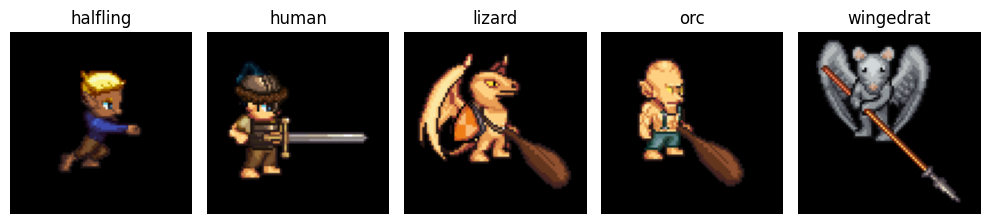

In [5]:
# Display one example image from each class
plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    # Select the first image path belonging to the current class
    example_path = df[df["label"] == class_name]["image_path"].iloc[0]
    img = Image.open(example_path)

    # Plot the example image with its class name as the title
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


### 2.4.3 Dataset Preprocessing

All images are converted to RGB format, resized to 80 x 80 pixels, and normalised by scaling pixel values to the range from 0 to 1. The labels are also converted from class names into integer indices so that they can be used for model training.


In [6]:
# Create empty lists to store preprocessed images and numeric labels
X = []
y = []

# Create mappings between class names and integer labels
label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

# Load, resize, normalise each image, and convert its label to an integer
for img_path, label in zip(df["image_path"], df["label"]):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32) / 255.0

    X.append(img_array)
    y.append(label_to_index[label])

# Convert lists into NumPy arrays for model input
X = np.array(X)
y = np.array(y)

# Print dataset shapes and label mapping information
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", label_to_index)


X shape: (8018, 80, 80, 3)
y shape: (8018,)
Classes: {'halfling': 0, 'human': 1, 'lizard': 2, 'orc': 3, 'wingedrat': 4}



The dataset is split into 70% training data, 15% validation data, and 15% test data. Stratified splitting is used to keep the class distribution as consistent as possible across each subset.


In [7]:
# Use the fixed random seed to make the data split reproducible.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (5612, 80, 80, 3) (5612,)
Validation: (1203, 80, 80, 3) (1203,)
Test: (1203, 80, 80, 3) (1203,)


### 2.4.4 KNN Preprocessing

KNN uses one-dimensional feature vectors instead of three-dimensional image tensors. Therefore, each 80 x 80 x 3 image is flattened into a vector with a length of 19,200.


In [8]:
# Flatten image tensors into one-dimensional feature vectors for KNN
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Check the flattened feature shape
print("Flattened training shape:", X_train_flat.shape)

# Standardise features so that each pixel feature has a similar scale
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_flat)
X_val_knn = scaler.transform(X_val_flat)
X_test_knn = scaler.transform(X_test_flat)


Flattened training shape: (5612, 19200)


### 2.4.5 KNN Model Training and Validation

This section tests multiple values of k and selects the final k based on validation accuracy. This avoids tuning the model directly on the test set. 


The candidate values `k = [1, 3, 5, 7, 9]` were selected to test a range of small neighbourhood sizes for the KNN classifier. Smaller values such as `k = 1` allow the model to make very local decisions, but they may be sensitive to noise and overfitting. Larger values such as `k = 7` or `k = 9` consider more neighbouring samples, which can make the prediction more stable but may also smooth out important class differences. Odd values were used to reduce the chance of tied votes during classification.


In [9]:
# Define the candidate k values to test
k_values = [1, 3, 5, 7, 9]
knn_results = []

# Train and validate a KNN model for each k value
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)

    # Evaluate the model on the validation set
    val_pred = knn.predict(X_val_knn)
    val_acc = accuracy_score(y_val, val_pred)

    # Store the validation result for comparison
    knn_results.append({
        "k": k,
        "validation_accuracy": val_acc,
    })

# Convert results into a DataFrame for easier display
knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,k,validation_accuracy
0,1,0.957606
1,3,0.962594
2,5,0.951787
3,7,0.948462
4,9,0.944306


**Table 1. Validation accuracy with different K**

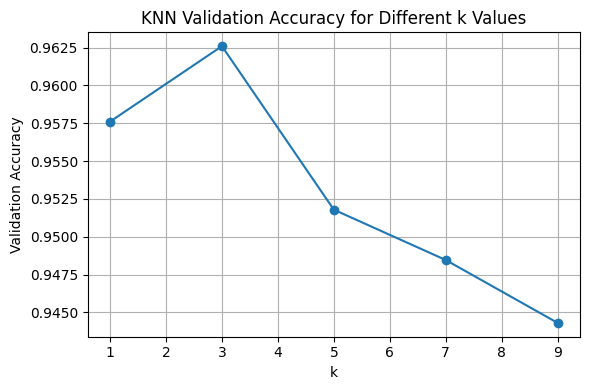

In [10]:
# Plot validation accuracy for each tested k value
plt.figure(figsize=(6, 4))
plt.plot(knn_results_df["k"], knn_results_df["validation_accuracy"], marker="o")

# Add chart title and axis labels
plt.title("KNN Validation Accuracy for Different k Values")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")

# Improve readability and layout
plt.grid(True)
plt.tight_layout()
plt.show()

**Figure 1. Visualisation of validation accuracy with different K**

Table 1 and Figure 1 show the validation accuracy obtained after training the KNN model with different k values on the training set. It can be seen that when `k = 3`, the validation accuracy is the highest, indicating the best performance among the tested values. Therefore, `k = 3` will be used for the subsequent test set evaluation.


### 2.4.6 KNN Test Set Evaluation

The final KNN model is retrained using the best k selected from the validation set, and then evaluated once on the test set for final performance assessment.

Precision, recall, F1-score, support, accuracy, macro average, weighted average, and the confusion matrix were used to evaluate the classification models. Accuracy measures the overall proportion of correctly classified images, while precision shows how many samples predicted as a certain class are actually correct. Recall measures how many true samples of a class are successfully identified, and F1-score combines precision and recall into a single balanced metric. Support indicates the number of true samples in each class. Macro average treats all classes equally by calculating the simple average across classes, while weighted average considers the number of samples in each class, giving more influence to larger classes. The confusion matrix provides a class-by-class view of correct and incorrect predictions, making it easier to identify which dungeon entity classes are confused with each other.

These metrics were selected because image classification performance cannot be fully explained by accuracy alone. Accuracy gives a useful overall result, but precision, recall, and F1-score provide more detailed information for each entity class. Macro and weighted averages help assess both balanced class performance and performance under the actual class distribution. The confusion matrix was included because it visually shows the error patterns between classes, which supports a more critical evaluation of model strengths and weaknesses.



In [11]:
# Select the k value with the highest validation accuracy
best_k = knn_results_df.sort_values("validation_accuracy", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Best k:", best_k)

# Train the final KNN model using the selected best k value
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_knn, y_train)

# Predict labels for the test set and calculate test accuracy
knn_test_pred = best_knn.predict(X_test_knn)
knn_test_acc = accuracy_score(y_test, knn_test_pred)

# Display final test accuracy and detailed classification metrics
print("KNN Test Accuracy:", knn_test_acc)
print(classification_report(y_test, knn_test_pred, target_names=class_names))

Best k: 3
KNN Test Accuracy: 0.9526184538653366
              precision    recall  f1-score   support

    halfling       0.92      0.93      0.93       199
       human       0.96      0.96      0.96       483
      lizard       0.99      0.93      0.96       226
         orc       0.92      0.95      0.94       207
   wingedrat       0.99      1.00      0.99        88

    accuracy                           0.95      1203
   macro avg       0.95      0.96      0.95      1203
weighted avg       0.95      0.95      0.95      1203



**Table 2. Results of KNN**

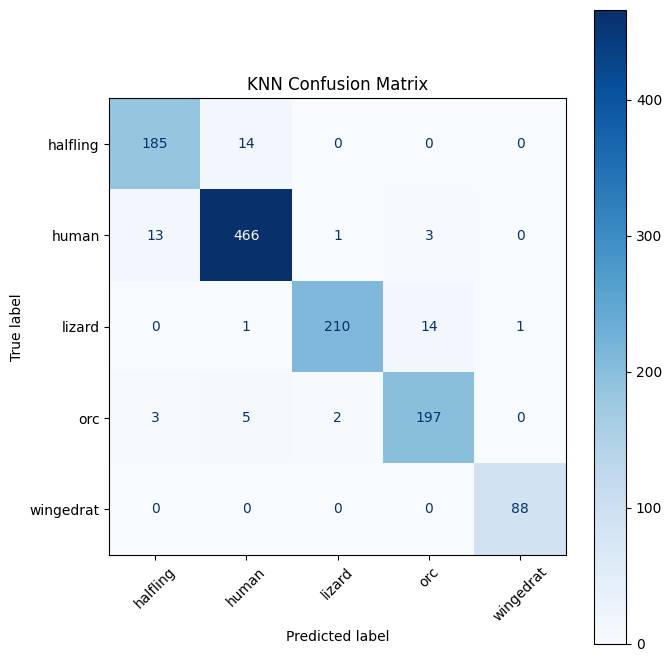

In [12]:
# Create the confusion matrix for KNN test predictions
cm_knn = confusion_matrix(y_test, knn_test_pred)

# Set up the confusion matrix display with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=class_names,
)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

**Figure 2. Confusion matrix of KNN**

The KNN model achieved a strong test accuracy of 0.953 when using the best value of `k = 3`, showing that the flattened and standardised image features were effective for this classification task. The macro average and weighted average F1-scores are both 0.95, which suggests that the model performed consistently across the different classes. From the confusion matrix, most samples were correctly classified along the diagonal. The `wingedrat` class achieved almost perfect recall, with 88 test samples correctly identified. However, some confusion can be observed between visually similar classes, such as `halfling` and `human`, and between `lizard` and `orc`. Overall, KNN provides a strong baseline result, although its performance still depends on pixel-level feature similarity rather than learning deeper visual patterns.


### 2.4.7 CNN Model Design

The hyperparameters of the CNN model were selected based on the size and nature of the dungeon image classification task. The input image size was set to `80 x 80 x 3`, which keeps enough visual information for recognising the entity shapes and colours while reducing computational cost compared with using larger images. 

Three convolutional layers with `32`, `64`, and `128` filters were used to learn visual features at increasing levels of complexity. The first layer learns simple low-level patterns such as edges and colours, while deeper layers can learn more complex shapes and entity-specific features. The `3 x 3` kernel size was chosen because it is widely used in CNN image classification models and can capture local image patterns effectively while keeping the number of parameters manageable. After each convolutional layer, `2 x 2` max pooling was applied to reduce the spatial size of the feature maps, lower computation, and make the model less sensitive to small position changes in the images.

A dense layer with `128` neurons was used after flattening the feature maps to provide enough capacity for final classification without making the model unnecessarily large. A dropout rate of `0.3` was added to reduce overfitting by randomly disabling part of the network during training. This is important because image classification models can easily memorise training samples, especially when the dataset is not very large. The final layer uses `softmax` activation because the task is a multi-class classification problem, where each image belongs to one of several entity classes.

The model was trained using the `Adam` optimiser because it is commonly used for deep learning tasks and adapts the learning rate during training, making it suitable when manual optimiser tuning is limited. The loss function was set to `sparse_categorical_crossentropy` because the class labels were encoded as integer indices rather than one-hot vectors. Overall, these hyperparameter choices provide a balanced CNN structure that is complex enough to learn meaningful visual features, but still small enough to train efficiently on the available environment.



In [13]:
# Get the number of output classes
num_classes = len(class_names)

# Build a sequential CNN model for image classification
cnn_model = models.Sequential([
    # Define the input image shape
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolution and pooling block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution and pooling block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution and pooling block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps and pass them into fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # Output layer for multi-class classification
    layers.Dense(num_classes, activation="softmax"),
])

# Compile the model with optimiser, loss function, and evaluation metric
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Display the model architecture and number of parameters
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,597 (4.36 MB)

 Trainable params: 1,142,597 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### 2.4.8 CNN Model Training

In the CNN training process, the maximum number of epochs was set to `30` to give the model enough opportunities to learn visual patterns from the training data without making training unnecessarily long. A batch size of `32` was used because it is a common and stable choice for image classification tasks, balancing training speed and gradient update reliability. Early stopping was applied by monitoring `val_loss`, because validation loss reflects how well the model generalises to unseen validation data. The patience value was set to `5`, meaning training stops if validation loss does not improve for five consecutive epochs. This helps reduce overfitting and avoids wasting computation. `restore_best_weights=True` was used so that the final model keeps the weights from the epoch with the best validation performance rather than the last epoch.



In [14]:
# Set up early stopping to stop training when validation loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

# Train the CNN model using the training set and validate it on the validation set
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - accuracy: 0.8583 - loss: 0.3895 - val_accuracy: 0.9709 - val_loss: 0.0999
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9804 - loss: 0.0657 - val_accuracy: 0.9809 - val_loss: 0.0461
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9882 - loss: 0.0343 - val_accuracy: 0.9909 - val_loss: 0.0241
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9941 - loss: 0.0196 - val_accuracy: 0.9900 - val_loss: 0.0241
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9968 - loss: 0.0113 - val_accuracy: 0.9892 - val_loss: 0.0247
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9980 - loss: 0.0077 - val_accuracy: 0.9925 - val_loss: 0.0398
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9975 - loss: 0.0070 - val_accuracy: 0.9925 - val_loss: 0.0235
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9925 - loss: 0.0227 - 

Accuracy and loss curves can help determine whether a model is learning correctly and whether overfitting has occurred. A sustained increase in training accuracy coupled with a decline in validation performance usually indicates that the model may be overfitting.

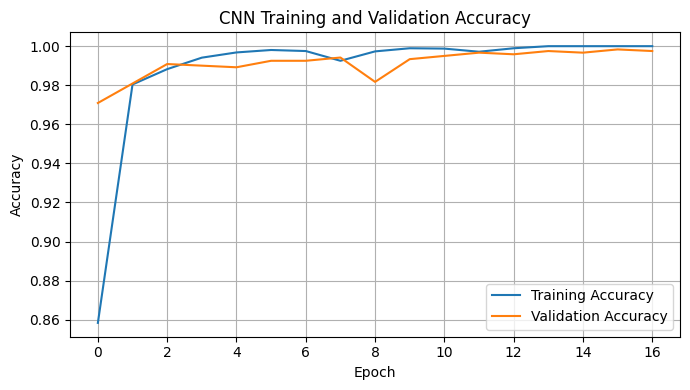

In [15]:
# Convert the training history into a DataFrame for easier plotting
history_df = pd.DataFrame(history.history)

# Plot training and validation accuracy over epochs
plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

# Add chart title, labels, legend, and grid
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Figure 3. CNN training and validation accuracy**

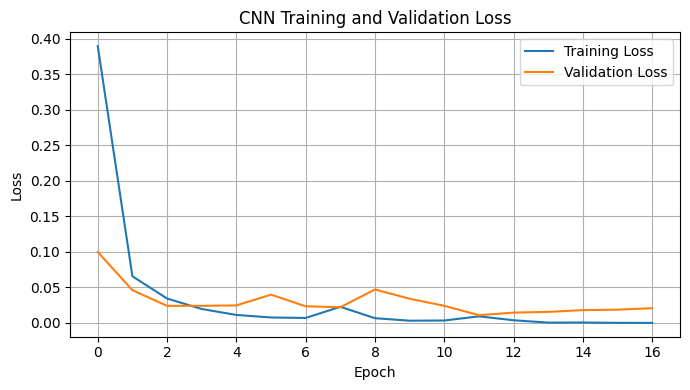

In [16]:
# Plot training and validation loss over epochs
plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

# Add chart title, labels, legend, and grid
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Figure 4. CNN training and validation Loss**

### 2.4.9 CNN Test Set Evaluation

To ensure fairness, the same evaluation metrics used for KNN are also applied to the CNN model.


In [17]:
# Evaluate the trained CNN model on the test set
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)

# Display the final test loss and accuracy
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_acc)

# Predict class probabilities for the test images
cnn_test_probs = cnn_model.predict(X_test)

# Convert predicted probabilities into final class labels
cnn_test_pred = np.argmax(cnn_test_probs, axis=1)

# Display detailed classification metrics for each class
print(classification_report(y_test, cnn_test_pred, target_names=class_names))


CNN Test Loss: 0.036236055195331573
CNN Test Accuracy: 0.9900249242782593
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

    halfling       0.99      1.00      1.00       199
       human       1.00      1.00      1.00       483
      lizard       0.98      0.99      0.98       226
         orc       0.98      0.97      0.97       207
   wingedrat       0.98      1.00      0.99        88

    accuracy                           0.99      1203
   macro avg       0.99      0.99      0.99      1203
weighted avg       0.99      0.99      0.99      1203



**Table 3. Results of CNN**

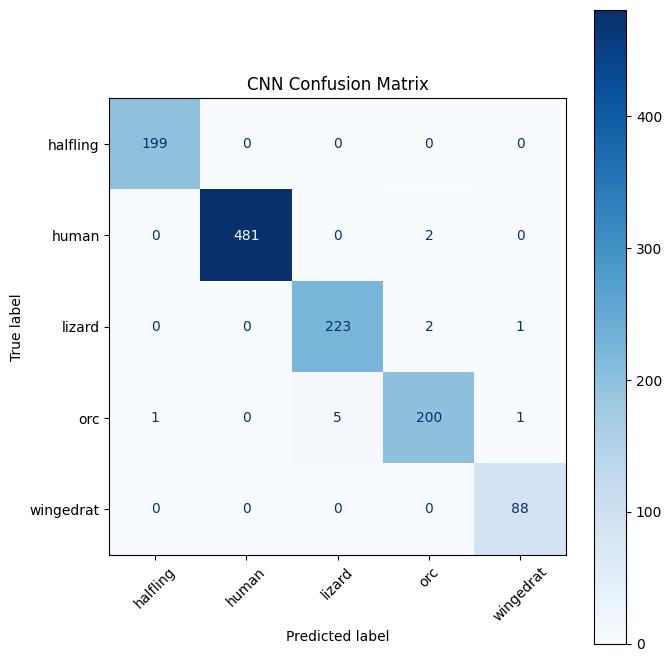

In [18]:
# Create the confusion matrix for CNN test predictions
cm_cnn = confusion_matrix(y_test, cnn_test_pred)

# Set up the confusion matrix display with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=class_names,
)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()


**Figure 5. Confusion matrix of CNN**


From Figure 3 and 4, the CNN model achieved very strong performance on the test set, with a test accuracy of 0.990 and macro and weighted average F1-scores of 0.99. The training and validation accuracy curves show that the model learned quickly, reaching high accuracy within the first few epochs, while the loss curves decreased sharply and remained low. Although the maximum number of epochs was set to 30, training stopped earlier because early stopping was triggered when the validation loss no longer improved. This helped reduce unnecessary training and lowered the risk of overfitting.

Table 3 and confusion matrix show that most classes were classified almost perfectly, especially `human` , which achieved full recall. However, a small number of errors still occurred, mainly between `lizard` and `orc`, suggesting that these two classes may share similar visual features. 


## 2.5 Comparison with KNN and CNN

<p align="left">
  <img src="../figures/compare_KNN_CNN_confusion_matrix.png" width="800">
</p>

<p align="left"><b>Figure 6. Confusion matrix comparison of KNN and CNN</b></p>

<p align="left">
  <img src="../figures/compare_KNN_CNN_results.png" width="800">
</p>

<p align="left"><b>Figure 7. Results comparison of KNN and CNN</b></p>


From Figure 6 and 7, the results show that both supervised learning models performed well on the dungeon entity image classification task, but the CNN clearly achieved better overall performance than KNN. The KNN model reached a test accuracy of 0.953, with macro and weighted average F1-scores of 0.95, showing that it worked as a strong traditional machine learning baseline. However, its confusion matrix shows more classification errors, especially between `halfling` and `human`, and between `lizard` and `orc`. This suggests that KNN has difficulty separating visually similar classes because it relies on flattened pixel-level feature similarity and does not explicitly learn spatial image patterns. In contrast, the CNN achieved a much higher test accuracy of 0.990, with macro and weighted average F1-scores of 0.99. Its confusion matrix contains far fewer errors, showing that the CNN was more effective at learning visual and spatial features from the images.

## 2.6 Task 1 Limitation and Future Work

Overall, Task 1 successfully implemented a complete supervised learning workflow, including image loading, preprocessing, train-validation-test splitting, KNN hyperparameter selection, CNN model training, and evaluation using accuracy, classification reports, and confusion matrices. The comparison between KNN and CNN is meaningful because it shows the difference between a simple baseline model and a deep learning model designed for image classification. However, there are also some limitations. First, KNN uses flattened images, so it ignores spatial relationships between pixels. Second, the CNN architecture is relatively simple and was not compared with more advanced architectures or transfer learning models. Third, the dataset appears to have some class imbalance, such as the smaller number of `wingedrat` samples compared with `human`, which may affect the reliability of performance comparison across classes. In addition, the evaluation is based on a single train-validation-test split, so the results may depend on this particular split.

For future work, data augmentation could be added to improve model generalisation, especially for classes with fewer samples. More CNN architectures or transfer learning models could also be tested to see whether performance can be improved further. Cross-validation or repeated experiments with different random seeds could make the evaluation more reliable. Finally, analysing misclassified images in more detail would help explain why certain classes, such as `lizard` and `orc`, are still occasionally confused.



# 3. Task 2: Sensor/Stats Clustering with Unsupervised Learning Approaches


## 3.1 Task Description and Scope

The objective of Task 2 is to investigate whether dungeon entities can be grouped meaningfully using their sensor and statistical attributes rather than image pixels. The dataset contains entity-level features such as stench, sound, intelligence, weight, height, strength, heat, magic, flight, and bribe, together with a true `species` label.

The scope of this task includes loading and inspecting the feature dataset, separating the true label from the model input, preprocessing numerical and categorical features, applying K-Means and Gaussian Mixture Model clustering, evaluating the discovered clusters, and critically comparing the two methods. The true `species` label is used only after clustering as an external reference for interpretation; it is not used to train the clustering models.


## 3.2 Approach Selection

Unsupervised learning is appropriate for this task because the aim is to discover structure in the feature space without giving the algorithms the true entity labels. This makes the task different from Task 1: instead of learning a mapping from input to known classes, the models must organise entities according to similarity in their measured attributes.

This design is useful for testing whether the sensor/statistical features contain enough information to separate entity types naturally. If the clusters align well with the hidden `species` labels during post-hoc evaluation, it provides evidence that the selected features capture meaningful differences between dungeon entities.


## 3.3 Algorithm Selection and Justification

K-Means and Gaussian Mixture Model (GMM) were selected because they represent two different clustering assumptions. K-Means is a distance-based method that assigns each sample to the nearest centroid. It is simple, efficient on a dataset of 10,000 rows, and provides a strong baseline for compact, roughly spherical clusters. Its main limitation is that it makes hard assignments and assumes clusters can be represented well by centroids.

GMM was selected as a probabilistic alternative. Instead of assigning samples only by nearest centroid, it models the data as a mixture of Gaussian distributions and can represent clusters with different covariance structures. This is useful if dungeon entity groups overlap or have different shapes in feature space. Comparing K-Means with GMM therefore tests whether a simple centroid-based model is sufficient or whether a more flexible probabilistic model improves the clustering.


## 3.4 Task 2 Implementation Process

This section presents the implementation process of Task 2. The code cells are kept together with short comments, while the Markdown text explains the design choices, hyperparameter selection, evaluation metrics, algorithm-specific results, comparison, and limitations.


### 3.4.1 Imports and Environment Setup

The following cells import the tools needed for data handling, preprocessing, dimensionality reduction, clustering, and evaluation. A fixed seed is used to make stochastic steps more reproducible.


In [19]:
# Import core libraries for file handling, randomness, numerical processing, data analysis, and visualisation
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Limit the number of computation threads to improve stability and reproducibility
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# Import preprocessing, pipeline, missing value handling, and dimensionality reduction tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Import clustering algorithms
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Import clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)


In [20]:
# Set a fixed random seed to make the experiment more reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


### 3.4.2 Loading and Inspecting the Dataset

The dataset is loaded from `dungeon_sensorstats.csv`. Before modelling, the notebook checks the shape, column types, summary statistics, missing values, and class distribution. This inspection is necessary because clustering is sensitive to feature scale, missing values, and irrelevant columns.


In [21]:
# Define the path to the dungeon sensor/statistical feature dataset
DATA_PATH = Path("../data/dungeon_sensorstats.csv")

# Load the dataset into a DataFrame
df = pd.read_csv(DATA_PATH)

# Display the first few rows of the dataset
df.head()


,species,stench,sound,intelligence,weight,height,strength,heat,magic,flight,bribe
0,winged_rat,360.0,53.0,33.370,349.2,315.689836,73.5,33.077273,0,1,0.0
1,lizard,303.0,43.5,130.480,355.5,323.612212,82.5,4.931818,0,1,0.0
2,halfling,66.0,14.0,150.400,116.1,207.695037,19.0,26.529545,0,0,0.0
3,lizard,327.0,28.5,155.380,370.2,316.605962,74.5,9.036364,0,1,0.0
4,lizard,321.0,49.0,166.585,193.8,227.480995,68.0,5.713636,0,0,0.0


In [22]:
# Print the number of rows and columns in the dataset
print("Dataset shape:", df.shape)

# Display column names, data types, and missing value information
df.info()


Dataset shape: (10000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   species       10000 non-null  object 
 1   stench        9975 non-null   float64
 2   sound         9970 non-null   float64
 3   intelligence  9972 non-null   float64
 4   weight        9966 non-null   float64
 5   height        9966 non-null   float64
 6   strength      9972 non-null   float64
 7   heat          9959 non-null   float64
 8   magic         10000 non-null  int64  
 9   flight        10000 non-null  int64  
 10  bribe         10000 non-null  float64
dtypes: float64(8), int64(2), object(1)
memory usage: 859.5+ KB


The dataset contains 10,000 rows and 11 columns. The `species` column is categorical and the remaining columns are numerical. Several numerical columns contain small numbers of missing values, so imputation is required before applying K-Means or GMM.


In [23]:
# Display all column names in the dataset as a list
df.columns.tolist()


['species',
 'stench',
 'sound',
 'intelligence',
 'weight',
 'height',
 'strength',
 'heat',
 'magic',
 'flight',
 'bribe']

In [24]:
# Generate summary statistics for all columns and transpose the result for easier reading
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,10000,5,winged_rat,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stench,9975.0,NaN,NaN,NaN,297.564211,176.877471,0.0,120.0,333.0,420.0,600.0
sound,9970.0,NaN,NaN,NaN,39.351264,23.880698,0.0,23.0,36.5,48.0,94.0
intelligence,9972.0,NaN,NaN,NaN,103.281813,58.547507,1.0,44.575,123.01,146.665,250.0
weight,9966.0,NaN,NaN,NaN,286.626069,109.907593,30.0,202.2,321.9,363.9,450.0
height,9966.0,NaN,NaN,NaN,294.732975,75.314098,71.521216,238.978083,310.32219,350.958944,474.301343
strength,9972.0,NaN,NaN,NaN,64.920929,26.569594,3.0,48.5,70.5,86.5,100.0
heat,9959.0,NaN,NaN,NaN,22.879518,10.491809,2.0,15.584091,25.454545,30.927273,45.0
magic,10000.0,NaN,NaN,NaN,0.05,0.217956,0.0,0.0,0.0,0.0,1.0
flight,10000.0,NaN,NaN,NaN,0.2961,0.456558,0.0,0.0,0.0,1.0,1.0


In [25]:
# Count missing values in each column and sort them in descending order
missing_values = df.isnull().sum().sort_values(ascending=False)

# Display only columns that contain missing values
missing_values[missing_values > 0]


heat            41
weight          34
height          34
sound           30
intelligence    28
strength        28
stench          25
dtype: int64

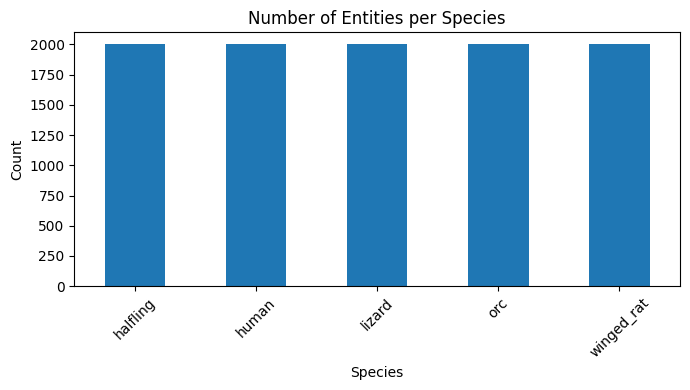

In [26]:
# Plot the number of entities in each species category
plt.figure(figsize=(7, 4))
df["species"].value_counts().sort_index().plot(kind="bar")

# Add chart title and axis labels
plt.title("Number of Entities per Species")
plt.xlabel("Species")
plt.ylabel("Count")

# Rotate x-axis labels and adjust layout for readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




The class distribution is balanced, with 2,000 samples for each species. Although these labels are not used during clustering, the balanced distribution makes the later external comparison easier to interpret because no species dominates the evaluation.


### 3.4.3 Dataset Preprocessing

The true `species` label is kept separately as `y_true` for later evaluation and is removed from the clustering input. Any ID-like columns are also removed because identifiers do not describe meaningful entity behaviour and could create artificial separations.

The remaining features are split into numerical and categorical groups. Numerical features are imputed using the median, which is robust to outliers, and then standardised with `StandardScaler` so that variables such as `bribe`, `weight`, and `magic` do not dominate only because of scale differences. Categorical features, if present, are imputed with the most frequent value and one-hot encoded. This produces a clean processed matrix of shape `(10000, 10)` for PCA, K-Means, and GMM.


In [27]:
# Define possible names for the label column
possible_label_columns = ["species", "label", "class", "entity", "type", "target"]

# Initialise the detected label column as None
label_col = None

# Search for a column name that matches one of the possible label names
for col in df.columns:
    if col.lower() in possible_label_columns:
        label_col = col
        break

# Print the detected label column
print("Detected label column:", label_col)


Detected label column: species


In [28]:
# Separate the true label column from the input features if it exists
if label_col is not None:
    y_true = df[label_col]
    X_raw = df.drop(columns=[label_col])
else:
    y_true = None
    X_raw = df.copy()

# Identify ID-like columns, which should not be used for clustering
id_like_columns = [col for col in X_raw.columns if "id" in col.lower()]
print("ID-like columns removed:", id_like_columns)

# Remove ID-like columns from the feature dataset
X_raw = X_raw.drop(columns=id_like_columns)

# Display the first few rows of the raw input features
X_raw.head()


ID-like columns removed: []


,stench,sound,intelligence,weight,height,strength,heat,magic,flight,bribe
0,360.0,53.0,33.370,349.2,315.689836,73.5,33.077273,0,1,0.0
1,303.0,43.5,130.480,355.5,323.612212,82.5,4.931818,0,1,0.0
2,66.0,14.0,150.400,116.1,207.695037,19.0,26.529545,0,0,0.0
3,327.0,28.5,155.380,370.2,316.605962,74.5,9.036364,0,1,0.0
4,321.0,49.0,166.585,193.8,227.480995,68.0,5.713636,0,0,0.0


In [29]:
# Run this cell to generate the intermediate results used in this section.
numeric_cols = X_raw.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['stench', 'sound', 'intelligence', 'weight', 'height', 'strength', 'heat', 'magic', 'flight', 'bribe']
Categorical columns: []


In [30]:
# Run this cell to generate the intermediate results used in this section.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X_raw)

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

print("Processed feature type:", type(X_processed))
print("Processed feature shape:", X_processed.shape)

Processed feature type: <class 'numpy.ndarray'>
Processed feature shape: (10000, 10)


The preprocessing strategy supports fair distance-based clustering. Standardisation is especially important for K-Means because Euclidean distances are directly affected by feature scale. It is also useful for GMM because features with very large numeric ranges can dominate the fitted Gaussian components.


### 3.4.4 PCA Visualisation

PCA is used only for visualisation. The clustering algorithms are still trained on the full preprocessed feature matrix rather than on the two principal components. The first two principal components explain about 70.47% of the variance, which is sufficient for a useful two-dimensional overview but not enough to replace the full feature space for modelling.


In [31]:
# Create a PCA model to reduce the processed features to two dimensions
pca_2d = PCA(n_components=2, random_state=SEED)

# Fit PCA to the processed feature matrix and transform it into 2D
X_pca_2d = pca_2d.fit_transform(X_processed)

# Print how much variance is explained by each principal component
print("Explained variance ratio:", pca_2d.explained_variance_ratio_)

# Print the total variance explained by the two principal components
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())


Explained variance ratio: [0.54003289 0.16470338]
Total explained variance: 0.7047362739903925


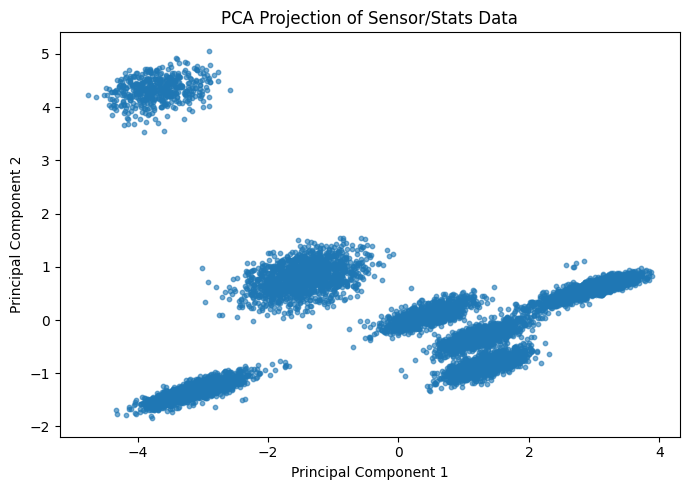

In [32]:
# Create a scatter plot of the data projected onto the first two principal components
plt.figure(figsize=(7, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=10, alpha=0.6)

# Add chart title and axis labels
plt.title("PCA Projection of Sensor/Stats Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Figure 8. PCA projection of the processed sensor/statistical features**

The PCA plot provides an initial visual check of whether the feature space contains separable regions. Because PCA compresses ten processed features into two dimensions, overlap in this plot should not be treated as complete evidence that the full-dimensional clusters overlap.


### 3.4.5 K-Means Clustering

For K-Means, the number of clusters `k` is treated as the main hyperparameter. Candidate values from `2` to `10` are evaluated to cover simpler and more detailed cluster structures. The true number of species is five, but the model is not forced to use five clusters because the feature space may split one species into subgroups or merge similar species.

The model uses `random_state=42` for reproducibility, `n_init=10` to reduce sensitivity to a poor centroid initialisation, and the `elkan` algorithm for efficient K-Means updates. The final `k` is selected mainly by silhouette score, with Davies-Bouldin score, Calinski-Harabasz score, and inertia used as supporting evidence.

The Davies-Bouldin score evaluates clustering quality by comparing within-cluster compactness and between-cluster separation. A lower Davies-Bouldin score indicates better clustering performance, as clusters are more compact and more clearly separated(Rubiños et al., 2024).

The Calinski-Harabasz score measures the ratio between between-cluster dispersion and within-cluster dispersion. A higher Calinski-Harabasz score indicates better clustering performance, as the clusters are more distinct and internally compact(Rubiños et al., 2024).



In [33]:
# Define the sample size used for computationally expensive clustering metrics.
metric_sample_size = min(3000, X_processed.shape[0])
print("Silhouette sample size:", metric_sample_size)

Silhouette sample size: 3000


This code sets the sample size used for computationally expensive clustering metrics. Since the dataset contains 10,000 samples, a maximum of 3,000 samples is used for metrics such as the silhouette score to reduce computation time while still providing a representative evaluation.

In [34]:
# Define candidate numbers of clusters to test
k_values = range(2, 11)
kmeans_results = []

# Train and evaluate K-Means models with different k values
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10,
        algorithm="elkan"
    )

    # Fit K-Means and assign each sample to a cluster
    cluster_labels = kmeans.fit_predict(X_processed)

    # Calculate clustering evaluation metrics
    sil = silhouette_score(
        X_processed,
        cluster_labels,
        sample_size=metric_sample_size,
        random_state=SEED
    )
    db = davies_bouldin_score(X_processed, cluster_labels)
    ch = calinski_harabasz_score(X_processed, cluster_labels)

    # Store the results for comparison
    kmeans_results.append({
        "k": k,
        "silhouette_score": sil,
        "davies_bouldin_score": db,
        "calinski_harabasz_score": ch,
        "inertia": kmeans.inertia_
    })

# Convert the results into a DataFrame for easier display
kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df


,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score,inertia
0,2,0.440073,1.040768,8226.176928,54861.188188
1,3,0.423911,1.049728,6755.819441,42524.792908
2,4,0.483984,0.880928,7944.248474,29548.834505
3,5,0.577060,0.694971,10682.002928,18957.566489
4,6,0.640441,0.589933,18081.034667,9954.265228
5,7,0.655263,0.536317,21403.911483,7219.516637
6,8,0.595562,0.667949,20159.367359,6612.511456
7,9,0.532697,0.929534,18674.200916,6268.499106
8,10,0.463723,1.098891,17288.259578,6033.208901


**Table 4. K-Means validation metrics for candidate k values**

The best silhouette score is obtained at `k = 7` with a silhouette score of `0.655`, Davies-Bouldin score of `0.536`, and Calinski-Harabasz score of `21403.91`. This suggests that seven clusters provide the clearest internal separation among the tested K-Means settings.


The figures below are visualizations of various indicators.

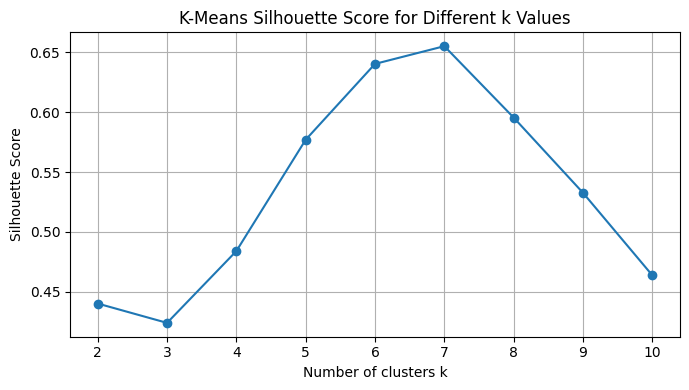

In [35]:
# Plot the silhouette score for each tested k value
plt.figure(figsize=(7, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["silhouette_score"], marker="o")

# Add chart title and axis labels
plt.title("K-Means Silhouette Score for Different k Values")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")

# Improve readability and display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


**Figure 9. K-Means silhouette score for different k values**


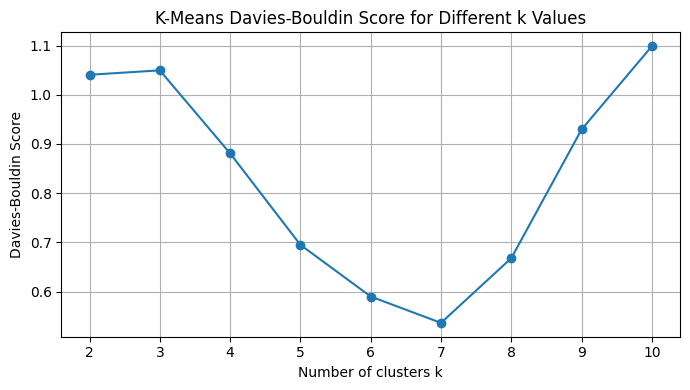

In [36]:
# Plot the Davies-Bouldin score for each tested k value
plt.figure(figsize=(7, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["davies_bouldin_score"], marker="o")

# Add chart title and axis labels
plt.title("K-Means Davies-Bouldin Score for Different k Values")
plt.xlabel("Number of clusters k")
plt.ylabel("Davies-Bouldin Score")

# Improve readability and display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


**Figure 10. K-Means Davies-Bouldin score for different k values**


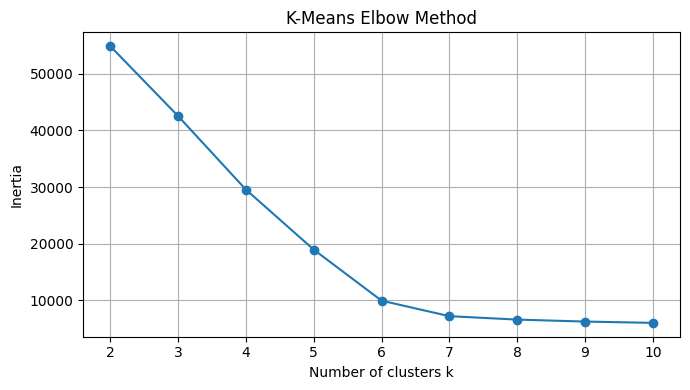

In [37]:
# Plot inertia for each tested k value to support the elbow method
plt.figure(figsize=(7, 4))
plt.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")

# Add chart title and axis labels
plt.title("K-Means Elbow Method")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")

# Improve readability and display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


**Figure 11. K-Means elbow curve based on inertia**


In [38]:
# Run K-Means clustering or visualise its evaluation results.
best_kmeans_row = kmeans_results_df.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

best_k = int(best_kmeans_row["k"])

print("Best k based on silhouette score:", best_k)
best_kmeans_row

Best k based on silhouette score: 7


k                              7.000000
silhouette_score               0.655263
davies_bouldin_score           0.536317
calinski_harabasz_score    21403.911483
inertia                     7219.516637
Name: 5, dtype: float64

In [39]:
# Create the final K-Means model using the selected best k value
best_kmeans = KMeans(
    n_clusters=best_k,
    random_state=SEED,
    n_init=10,
    algorithm="elkan"
)

# Fit the final K-Means model and get cluster labels for all samples
kmeans_labels = best_kmeans.fit_predict(X_processed)

# Add the K-Means cluster labels to the original DataFrame
df["kmeans_cluster"] = kmeans_labels

# Display the true species and assigned K-Means cluster for comparison
df[["species", "kmeans_cluster"]].head()


,species,kmeans_cluster
0,winged_rat,2
1,lizard,4
2,halfling,0
3,lizard,4
4,lizard,6


Some `lizard` samples are assigned to different clusters, suggesting that this species may contain subgroups in the feature space.

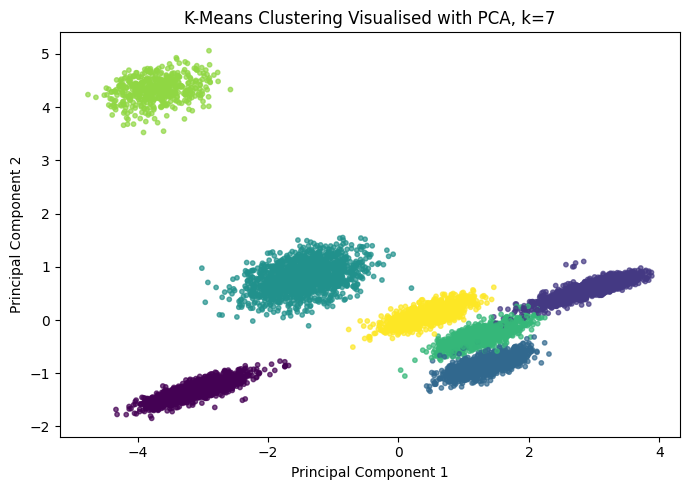

In [40]:
# Visualise the final K-Means clustering result using the first two PCA components
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    s=10,
    alpha=0.7
)

# Add chart title and axis labels
plt.title(f"K-Means Clustering Visualised with PCA, k={best_k}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Figure 12. K-Means clusters visualised with PCA**

K-Means selected `k = 7`, which is larger than the five true species. The post-hoc crosstab later shows why: some species, especially `human` and `lizard`, are split into multiple clusters. This is not necessarily an error in unsupervised learning; it may indicate meaningful subgroups in the statistical feature space.


### 3.4.6 Gaussian Mixture Model Clustering

For GMM, the number of mixture components is the main hyperparameter. Candidate component counts from `2` to `10` are tested, matching the K-Means search range for a fair comparison. A `full` covariance matrix is used because it allows each Gaussian component to model feature correlations rather than assuming independent or equally shaped clusters. The model uses `random_state=42` for reproducibility and `init_params="random_from_data"` to initialise components from actual data points.

GMM is evaluated with both clustering metrics and information criteria. The final number of components is selected by the lowest BIC, because BIC rewards likelihood but penalises unnecessary model complexity more strongly than AIC. This reduces the chance of selecting an overly complex mixture model only because it fits the training data better.


In [41]:
# Create an empty list to store GMM evaluation results
gmm_results = []

# Train and evaluate GMM models with different numbers of components
for n in range(2, 11):
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=SEED,
        init_params="random_from_data"
    )

    # Fit the GMM model and assign each sample to a component
    gmm_labels_candidate = gmm.fit_predict(X_processed)

    # Calculate clustering evaluation metrics
    sil = silhouette_score(
        X_processed,
        gmm_labels_candidate,
        sample_size=metric_sample_size,
        random_state=SEED
    )
    db = davies_bouldin_score(X_processed, gmm_labels_candidate)
    ch = calinski_harabasz_score(X_processed, gmm_labels_candidate)

    # Store the evaluation results for comparison
    gmm_results.append({
        "n_components": n,
        "silhouette_score": sil,
        "davies_bouldin_score": db,
        "calinski_harabasz_score": ch,
        "aic": gmm.aic(X_processed),
        "bic": gmm.bic(X_processed)
    })

# Convert the results into a DataFrame for easier display
gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df


,n_components,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,2,0.272027,1.300422,3546.687077,14183.380104,15127.934692
1,3,0.380108,0.876990,4484.424811,-37538.038027,-36117.600974
2,4,0.512499,0.808142,7096.301470,-162564.596351,-160668.276834
3,5,0.541419,0.876220,7591.002341,-203885.747876,-201513.545894
4,6,0.438897,1.087258,6172.841663,-205306.824728,-202458.740281
5,7,0.411561,1.612009,5155.198980,-205848.101758,-202524.134846
6,8,0.395340,1.776995,6102.014993,-282822.683911,-279022.834535
7,9,0.496752,1.243611,11851.278893,-265698.930113,-261423.198273
8,10,0.432052,1.687815,4033.787271,-233522.058022,-228770.443717


**Table 5. GMM validation metrics for candidate component counts**

The lowest BIC is obtained with `8` components. However, this setting has a silhouette score of `0.395` and Davies-Bouldin score of `1.777`, which are weaker than the selected K-Means model. This difference indicates that the likelihood-based GMM selection does not necessarily produce the clearest cluster separation under distance-based metrics.


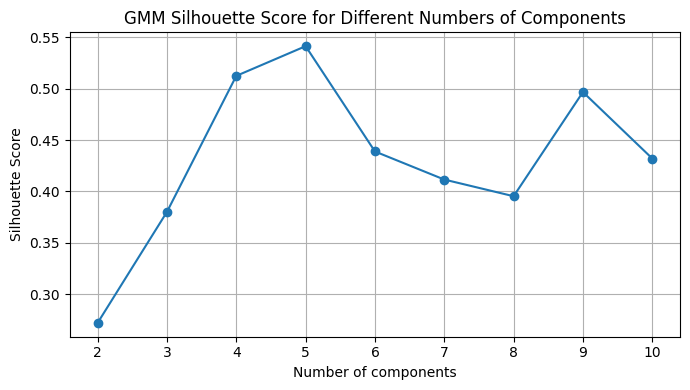

In [42]:
# Plot the silhouette score for each tested number of GMM components
plt.figure(figsize=(7, 4))
plt.plot(gmm_results_df["n_components"], gmm_results_df["silhouette_score"], marker="o")

# Add chart title and axis labels
plt.title("GMM Silhouette Score for Different Numbers of Components")
plt.xlabel("Number of components")
plt.ylabel("Silhouette Score")

# Improve readability and display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


**Figure 13. GMM silhouette score for different component counts**


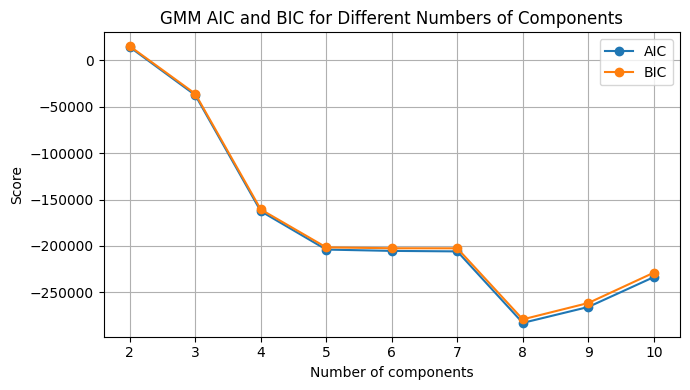

In [43]:
# Run GMM clustering or visualise its evaluation results.
plt.figure(figsize=(7, 4))
plt.plot(gmm_results_df["n_components"], gmm_results_df["aic"], marker="o", label="AIC")
plt.plot(gmm_results_df["n_components"], gmm_results_df["bic"], marker="o", label="BIC")
plt.title("GMM AIC and BIC for Different Numbers of Components")
plt.xlabel("Number of components")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Figure 14. GMM AIC and BIC for different component counts**


In [44]:
# Run GMM clustering or visualise its evaluation results.
best_gmm_row = gmm_results_df.sort_values(
    "bic",
    ascending=True
).iloc[0]

best_n_components = int(best_gmm_row["n_components"])

print("Best number of GMM components based on BIC:", best_n_components)
best_gmm_row

Best number of GMM components based on BIC: 8


n_components                    8.000000
silhouette_score                0.395340
davies_bouldin_score            1.776995
calinski_harabasz_score      6102.014993
aic                       -282822.683911
bic                       -279022.834535
Name: 6, dtype: float64

In [45]:
# Use the fixed random seed to keep the experiment reproducible.
best_gmm = GaussianMixture(
    n_components=best_n_components,
    covariance_type="full",
    random_state=SEED,
    init_params="random_from_data"
)

gmm_labels = best_gmm.fit_predict(X_processed)

df["gmm_cluster"] = gmm_labels

df[["species", "gmm_cluster"]].head()

,species,gmm_cluster
0,winged_rat,0
1,lizard,2
2,halfling,7
3,lizard,2
4,lizard,7


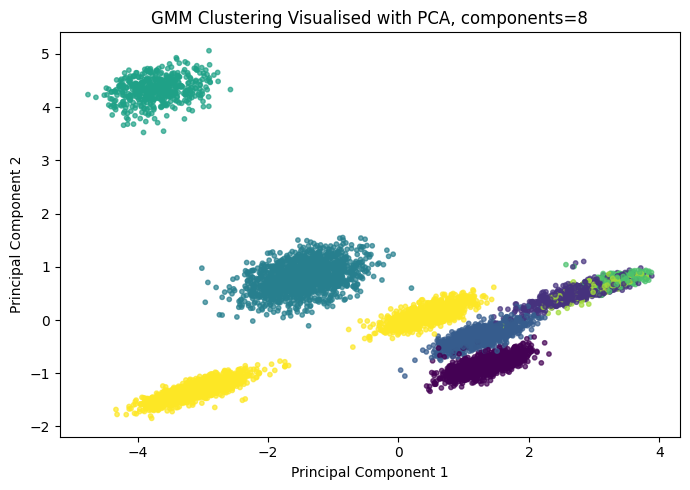

In [46]:
# Run GMM clustering or visualise its evaluation results.
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=gmm_labels,
    s=10,
    alpha=0.7
)
plt.title(f"GMM Clustering Visualised with PCA, components={best_n_components}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

**Figure 15. GMM clusters visualised with PCA**

Although the dataset has five known species, the GMM results show a conflict between BIC and silhouette score. The lowest BIC is obtained when `n_components = 8`, suggesting that an eight-component probabilistic model provides the best balance between likelihood fit and model complexity. This means that the data distribution may contain subgroups within some species, so more than five Gaussian components are useful for modelling the underlying feature distribution.

However, the highest silhouette score is obtained when `n_components = 5`. Silhouette score focuses on distance-based cluster separation and compactness, so this result suggests that five components produce more clearly separated clusters in the feature space. In contrast, the eight-component model may fit the probability distribution better, but it creates clusters that are less separated or more overlapping, leading to a lower silhouette score and a higher Davies-Bouldin score.

Therefore, the results indicate that the best model depends on the evaluation objective. If the aim is probabilistic density modelling, the eight-component GMM is preferred because it has the lowest BIC. If the aim is to obtain clearly separated and interpretable entity groups, the five-component GMM may be more suitable because it has the highest silhouette score. 


### 3.4.7 Evaluation Metrics and Model Comparison

Several metrics are used because clustering quality cannot be judged by a single number. Silhouette score measures how close samples are to their own cluster compared with other clusters, so higher values indicate better separation. Davies-Bouldin score measures similarity between clusters, so lower values are better. Calinski-Harabasz score compares between-cluster dispersion with within-cluster dispersion, so higher values are better. For GMM, AIC and BIC are also used because they evaluate probabilistic model fit while penalising complexity.

The true `species` labels are not used during training, but they are used after clustering for external evaluation. Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) measure how well the discovered clusters align with known species labels. This post-hoc evaluation is useful evidence, but it should not be confused with supervised training.


In [47]:
# Calculate final internal clustering metrics for the selected K-Means model
kmeans_final_metrics = {
    "Model": "K-Means",
    "Number of clusters/components": best_k,
    "Silhouette Score": silhouette_score(
        X_processed,
        kmeans_labels,
        sample_size=metric_sample_size,
        random_state=SEED
    ),
    "Davies-Bouldin Score": davies_bouldin_score(X_processed, kmeans_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_processed, kmeans_labels)
}

# Calculate final internal clustering metrics for the selected GMM model
gmm_final_metrics = {
    "Model": "Gaussian Mixture Model",
    "Number of clusters/components": best_n_components,
    "Silhouette Score": silhouette_score(
        X_processed,
        gmm_labels,
        sample_size=metric_sample_size,
        random_state=SEED
    ),
    "Davies-Bouldin Score": davies_bouldin_score(X_processed, gmm_labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(X_processed, gmm_labels)
}

# Combine the final metrics into a comparison table
comparison_df = pd.DataFrame([kmeans_final_metrics, gmm_final_metrics])
comparison_df


,Model,Number of clusters/components,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means,7,0.655263,0.536317,21403.911483
1,Gaussian Mixture Model,8,0.395340,1.776995,6102.014993


**Table 6. Final internal clustering metrics for K-Means and GMM**

K-Means achieves stronger internal clustering results than GMM: silhouette score `0.655` versus `0.395`, Davies-Bouldin score `0.536` versus `1.777`, and Calinski-Harabasz score `21403.91` versus `6102.01`. These results indicate that, when the GMM clustering effect is measured by the `BIC` score, the K-means algorithm produces more compact and better-separated clusters in the processed feature space.


| Metric | Better direction | Reason for use |
| --- | --- | --- |
| Silhouette Score | Higher is better | Measures both within-cluster compactness and between-cluster separation. |
| Davies-Bouldin Score | Lower is better | Penalises clusters that are close together or internally spread out. |
| Calinski-Harabasz Score | Higher is better | Rewards large between-cluster separation relative to within-cluster variance. |
| AIC/BIC | Lower is better | Selects GMM complexity while penalising overfitting, especially with BIC. |
| ARI/NMI | Higher is better | Measures post-hoc alignment with the hidden true species labels. |


In [48]:
# Calculate external clustering metrics only if true labels are available
if y_true is not None:
    # Compare K-Means clusters with the true species labels
    print("K-Means Adjusted Rand Index:", adjusted_rand_score(y_true, kmeans_labels))
    print("K-Means Normalized Mutual Information:", normalized_mutual_info_score(y_true, kmeans_labels))

    # Compare GMM clusters with the true species labels
    print("GMM Adjusted Rand Index:", adjusted_rand_score(y_true, gmm_labels))
    print("GMM Normalized Mutual Information:", normalized_mutual_info_score(y_true, gmm_labels))
else:
    # Skip external evaluation if there are no true labels
    print("No ground-truth label column was detected, so external clustering metrics were not calculated.")


K-Means Adjusted Rand Index: 0.882420696571732
K-Means Normalized Mutual Information: 0.9264394716311045
GMM Adjusted Rand Index: 0.6821730735328858
GMM Normalized Mutual Information: 0.8155051681159837


ARI and NMI are external clustering evaluation metrics that compare the predicted cluster labels with the true class labels, where higher values indicate better agreement between the clustering result and the known categories.


In [49]:
# Run K-Means clustering or visualise its evaluation results.
if y_true is not None:
    kmeans_crosstab = pd.crosstab(y_true, kmeans_labels)
    gmm_crosstab = pd.crosstab(y_true, gmm_labels)

    display(kmeans_crosstab)
    display(gmm_crosstab)

col_0,0,1,2,3,4,5,6
species,,,,,,,
halfling,2000,0,0,0,0,0,0
human,0,0,0,1500,0,500,0
lizard,0,0,3,0,958,0,1039
orc,0,2000,0,0,0,0,0
winged_rat,0,0,2000,0,0,0,0


col_0,0,1,2,3,4,5,6,7
species,,,,,,,,
halfling,0,0,0,0,0,0,0,2000
human,0,0,0,1500,500,0,0,0
lizard,4,0,957,0,0,0,0,1039
orc,0,1224,0,0,0,426,350,0
winged_rat,2000,0,0,0,0,0,0,0


**Table 7. External clustering alignment and species-cluster crosstabs**

K-Means achieves ARI `0.882` and NMI `0.926`, while GMM achieves ARI `0.682` and NMI `0.816`. This means K-Means aligns more closely with the true species labels. The crosstabs show that K-Means perfectly separates `halfling`, `orc`, and `winged_rat`, while `human` and `lizard` are split into subgroups. GMM also separates several groups, but it splits `orc` across multiple components and shows weaker overall alignment.


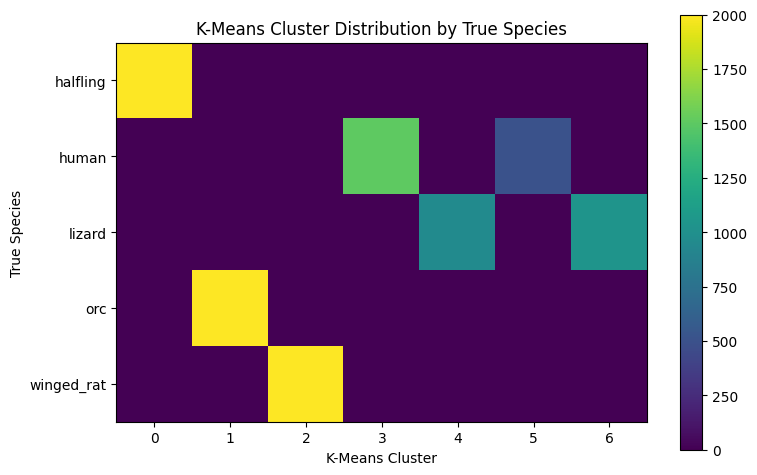

In [50]:
# Run K-Means clustering or visualise its evaluation results.
if y_true is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(kmeans_crosstab.values)

    ax.set_xticks(np.arange(kmeans_crosstab.shape[1]))
    ax.set_yticks(np.arange(kmeans_crosstab.shape[0]))
    ax.set_xticklabels(kmeans_crosstab.columns)
    ax.set_yticklabels(kmeans_crosstab.index)

    plt.xlabel("K-Means Cluster")
    plt.ylabel("True Species")
    plt.title("K-Means Cluster Distribution by True Species")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

**Figure 16. K-Means cluster distribution by true species**


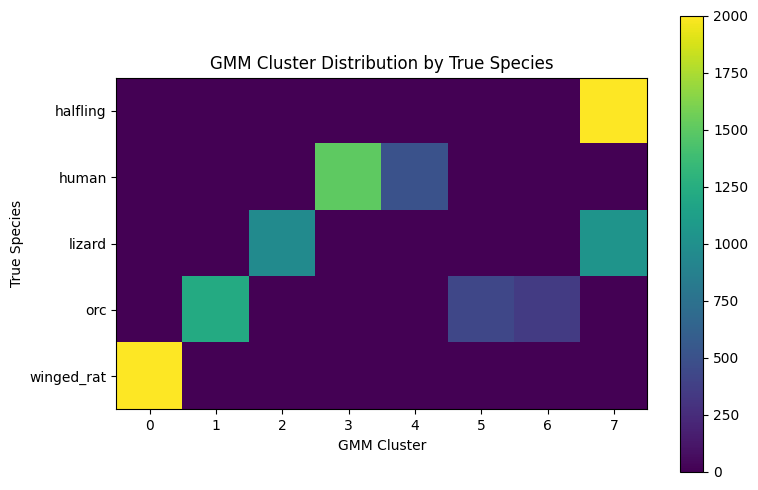

In [51]:
# Run GMM clustering or visualise its evaluation results.
if y_true is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(gmm_crosstab.values)

    ax.set_xticks(np.arange(gmm_crosstab.shape[1]))
    ax.set_yticks(np.arange(gmm_crosstab.shape[0]))
    ax.set_xticklabels(gmm_crosstab.columns)
    ax.set_yticklabels(gmm_crosstab.index)

    plt.xlabel("GMM Cluster")
    plt.ylabel("True Species")
    plt.title("GMM Cluster Distribution by True Species")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

**Figure 17. GMM cluster distribution by true species**


The external labels are used only for interpretation after clustering has already been completed. This preserves the unsupervised nature of the task while still allowing the discovered clusters to be evaluated against known entity categories.


### 3.4.8 Saving the Clustering Results


In [52]:
# Save the clustering results so they can be reused in the report and later analysis.
OUTPUT_PATH = Path("../report/task2_clustering_results.csv")

OUTPUT_PATH.parent.mkdir(exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print("Saved clustering results to:", OUTPUT_PATH)

Saved clustering results to: ..\report\task2_clustering_results.csv


## 3.5 Comparison Between K-Means and GMM

K-Means performs better than GMM in this task according to both internal and external metrics. Its selected seven-cluster solution has a higher silhouette score, lower Davies-Bouldin score, and higher Calinski-Harabasz score. It also has stronger agreement with the true species labels, with ARI `0.882` and NMI `0.926`.

A separate analysis of K-Means shows that the model is particularly strong at identifying compact species groups. `halfling`, `orc`, and `winged_rat` are separated cleanly, while `human` and `lizard` are divided into subclusters. This suggests that the sensor/statistical features may contain within-species variation rather than matching exactly one cluster per species.

A separate analysis of GMM shows that its greater flexibility does not improve the final clustering here. Although BIC selects eight components, the resulting clusters are less clearly separated by silhouette and Davies-Bouldin scores. The GMM crosstab also shows more fragmentation for some species, especially `orc`. In this dataset, the simpler centroid-based assumption of K-Means appears to match the feature structure better than the full-covariance probabilistic model.

However, if the silhouette score is selected as the main evaluation metric for GMM, GMM may outperform K-means. This could be explored further in future research.


## 3.6 Task 2 Limitations and Future Work

A key limitation is that internal clustering metrics do not always correspond to semantically meaningful dungeon entity groups. K-Means selecting seven clusters instead of five shows that the feature space may represent subtypes, noise, or feature-driven partitions rather than exactly the known species labels. Another limitation is that standardisation and one-hot encoding are reasonable general preprocessing choices, but they may not capture domain-specific relationships between features.

Future work could test hierarchical clustering or DBSCAN to identify non-spherical structures and possible outliers. Feature engineering could also be improved by adding ratios or interaction features, such as strength-to-weight or heat-to-magic relationships. Finally, the clusters could be analysed qualitatively by inspecting the feature profiles of each cluster, which would make the interpretation more useful for dungeon behaviour modelling.


# 4. Task 3: Reinforcement Learning in a Combat Maze


## 4.1 Task Description and Scope

Task 3 extends the original maze navigation environment into a reinforcement learning problem with both navigation and combat decisions. HeroBot must reach the target while avoiding collision with live monsters and choosing the correct weapon when a monster is in front of it.

The scope of this task includes adapting the environment, defining a discrete state representation, designing rewards, creating two baseline policies, training Q-learning and SARSA agents, evaluating them on validation and test mazes, and critically analysing their strengths and weaknesses.


## 4.2 Approach Selection

Reinforcement learning is used because the agent learns by interacting with an environment and receiving rewards or penalties from sequential actions. This is different from Task 1 and Task 2 because the quality of an action depends on future consequences. For example, moving forward may be useful on an empty cell, dangerous when a monster is ahead, or successful when the target is ahead.

A tabular approach is appropriate because the environment uses a small grid, a finite action space, and a deliberately compact discrete state representation. This makes Q-learning and SARSA suitable first methods before considering deep reinforcement learning.


## 4.3 Algorithm Selection and Justification

Q-learning and SARSA were selected because they are classic value-based reinforcement learning algorithms for discrete state-action spaces. Q-learning is an off-policy method: it updates each state-action value toward the best possible next action. This can make it more optimistic and more focused on learning a greedy policy.

SARSA is an on-policy method: it updates using the next action actually selected by the current exploratory policy. In risky environments, SARSA can sometimes learn safer behaviour because exploration risk is included in the update. Comparing these two methods is meaningful in this task because wrong weapon use, wall hits, and monster collisions create a safety-sensitive navigation problem.


## 4.4 Task 3 Implementation Process

This section explains the reinforcement learning implementation, including environment adaptation, state and reward design, baseline selection, hyperparameters, training curves, validation/test evaluation, algorithm-specific analysis, comparison, limitations, and future work.


### 4.4.1 Imports, Paths, and Experiment Settings

The following cells import the RL dependencies and locate the original dungeon maze environment. The experiment uses separate maze seed ranges for training, validation, and testing: train seeds `0-99`, validation seeds `100-124`, and test seeds `125-149`. This split is important for generalisation because the final evaluation should use mazes that were not used to update the Q-tables.

The grid size is set to `8`, which keeps the problem small enough for tabular learning while still allowing different maze layouts. Training uses `3000` episodes and a maximum of `500` steps per episode. The step limit prevents infinite loops and makes failures measurable.


In [53]:
# Import libraries for file paths, system setup, randomness, and default dictionaries
from pathlib import Path
import os
import sys
import random
from collections import defaultdict

# Import libraries for numerical processing, data logging, and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import tools for defining the RL action space and handling image assets
from gymnasium import spaces
from PIL import Image


In [54]:
# Locate the project and RL environment folders, then add the environment source code to Python path.
PROJECT_ROOT = Path("..").resolve()
RL_ROOT = PROJECT_ROOT / "RL" / "SEMTM0016_DungeonMazeWorld-main"

print("RL root:", RL_ROOT)
print("Exists:", RL_ROOT.exists())

if str(RL_ROOT) not in sys.path:
    sys.path.append(str(RL_ROOT))


RL root: D:\AAA超级无敌布里斯托\6_AIR_Artificial Intelligence for Robotics\ASST\submit\my_coursework\RL\SEMTM0016_DungeonMazeWorld-main
Exists: True


In [55]:
# Define train, validation, and test seeds together with grid size and training limits.
SEED = 42
TRAIN_SEEDS = list(range(0, 100))
VALIDATION_SEEDS = list(range(100, 125))
TEST_SEEDS = list(range(125, 150))
GRID_SIZE = 8
N_TRAIN_EPISODES = 3000
MAX_STEPS = 500

random.seed(SEED)
np.random.seed(SEED)

print("Train seeds:", TRAIN_SEEDS[0], "to", TRAIN_SEEDS[-1])
print("Validation seeds:", VALIDATION_SEEDS[0], "to", VALIDATION_SEEDS[-1])
print("Test seeds:", TEST_SEEDS[0], "to", TEST_SEEDS[-1])


Train seeds: 0 to 99
Validation seeds: 100 to 124
Test seeds: 125 to 149


### 4.4.2 Base Environment Check

The original environment provides maze generation, robot position, direction, wall layout, and target position. The following cells check that the required packages and environment classes are available before the combat extension is added.


In [56]:
# Check whether the current kernel has the basic packages required by the environment.
for package_name in ["gymnasium", "pygame"]:
    try:
        __import__(package_name)
        print(f"{package_name} is available")
    except ImportError:
        print(f"{package_name} is missing; install it before running the notebook")


gymnasium is available
pygame is available


In [57]:
# Import the maze environment, base action/direction enums, and existing monster classes.
from envs.simple_dungeonworld_env import DungeonMazeEnv, Actions, Directions
from core.dungeonworld_objects import Orc, Wingedbat, Lizard


In [58]:
# Create one base environment instance to inspect the original observations and action space.
base_env = DungeonMazeEnv(grid_size=GRID_SIZE)
base_obs, base_info = base_env.reset(seed=TRAIN_SEEDS[0])

print("Observation type:", type(base_obs))
print("Observation keys:", list(base_obs.keys()))
print("Robot position:", base_obs["robot_position"])
print("Target position:", base_obs["target_position"])
print("Base action space:", base_env.action_space)
print("Base actions:", {action.name: int(action) for action in Actions})


Observation type: <class 'dict'>
Observation keys: ['robot_position', 'robot_direction', 'robot_camera_view', 'target_position']
Robot position: [1 1]
Target position: [6 6]
Base action space: Discrete(3)
Base actions: {'turn_right': 0, 'turn_left': 1, 'move_forwards': 2}


### 4.4.3 Environment Adaptation

The original environment is extended with three monster types: `orc`, `wingedbat`, and `lizard`. The action space is expanded from three movement actions to five actions: turn right, turn left, move forward, use sword, and use bow. The weapon rules are deliberately simple but task-relevant: `orc` requires the sword, `wingedbat` requires the bow, and `lizard` can be killed by either weapon.

This adaptation turns the task from pure navigation into navigation plus conditional interaction. HeroBot must not only reach the target but also interpret the object in front of it and choose the correct response.


In [59]:
# Map the original movement actions from the base environment
TURN_RIGHT = int(Actions.turn_right)
TURN_LEFT = int(Actions.turn_left)
MOVE_FORWARDS = int(Actions.move_forwards)

# Add two new combat actions
USE_SWORD = 3
USE_BOW = 4

# Store readable names for each action
ACTION_NAMES = {
    TURN_RIGHT: "turn_right",
    TURN_LEFT: "turn_left",
    MOVE_FORWARDS: "move_forwards",
    USE_SWORD: "use_sword",
    USE_BOW: "use_bow",
}

# Encode different front-cell types as integers for the RL state representation
FRONT_CELL_TO_INDEX = {
    "empty": 0,
    "wall": 1,
    "target": 2,
    "orc": 3,
    "wingedbat": 4,
    "lizard": 5,
}

# Create the reverse mapping from integer index to cell type
INDEX_TO_FRONT_CELL = {value: key for key, value in FRONT_CELL_TO_INDEX.items()}

# Define the reward values used by the reinforcement learning environment
REWARDS = {
    "step": -1,
    "wall": -5,
    "correct_kill": 10,
    "wrong_weapon": -5,
    "empty_attack": -2,
    "death": -50,
    "target": 100,
}

# Define the image folders used for monster visual assets
DATA_IMAGE_DIR = PROJECT_ROOT / "data" / "dungeon_image"
MONSTER_IMAGE_DIRS = {
    "orc": DATA_IMAGE_DIR / "orc",
    "wingedbat": DATA_IMAGE_DIR / "wingedrat",
    "lizard": DATA_IMAGE_DIR / "lizard",
}

# Store the set of monster types used in the environment
MONSTER_TYPES = set(MONSTER_IMAGE_DIRS)


In [60]:
# Define a monster object that can be displayed in the camera view and interacted with by weapons
class CombatMonster:
    """Monster object using coursework image assets and the same combat interface."""

    def __init__(self, monster_type, pos, image_path=None):
        self.type = monster_type
        self.pos = np.array(pos)
        self.image_path = image_path
        self.image = self._load_camera_image(image_path)

    def _load_camera_image(self, image_path):
        # Load a real monster image if available; otherwise use a grayscale placeholder
        if image_path is not None and Path(image_path).exists():
            with Image.open(image_path) as im:
                return np.array(im.convert("L").resize((20, 20)))

        shade = {"orc": 90, "wingedbat": 150, "lizard": 210}[self.type]
        return shade * np.ones((20, 20))

    def can_overlap(self):
        return True

    def get_camera_view(self):
        return self.image

    # Define which weapons can defeat each monster type
    def can_be_killed_by_sword(self):
        return self.type in {"orc", "lizard"}

    def can_be_killed_by_bow(self):
        return self.type in {"wingedbat", "lizard"}


# Extend the original maze environment with monsters, combat actions, and local perception
class CombatDungeonMazeEnv(DungeonMazeEnv):
    """Dungeon maze with context-dependent combat decisions."""

    def __init__(self, grid_size=8, monster_counts=None):
        super().__init__(grid_size=grid_size)

        # Expand the action space from movement-only actions to movement plus combat actions
        self.action_space = spaces.Discrete(len(ACTION_NAMES))
        self.monster_counts = monster_counts or {"orc": 1, "wingedbat": 1, "lizard": 1}

    def reset(self, seed=None, options=None):
        # Reset the base maze and then place monsters into walkable cells
        obs, info = super().reset(seed=seed, options=options)
        self._place_monsters()
        self.robot_camera_view = self.get_robot_camera_view()
        return self.get_observations(), info

    def get_observations(self):
        # Add front, left, and right cell-type information to the observation
        obs = super().get_observations()
        obs["front_cell_type"] = FRONT_CELL_TO_INDEX[self.get_front_cell_type()]
        obs["left_cell_type"] = FRONT_CELL_TO_INDEX[self.get_relative_cell_type("left")]
        obs["right_cell_type"] = FRONT_CELL_TO_INDEX[self.get_relative_cell_type("right")]
        return obs

    def _direction_vector(self, direction):
        # Convert robot direction into a movement vector
        direction_vectors = {
            int(Directions.north): np.array((0, -1)),
            int(Directions.east): np.array((1, 0)),
            int(Directions.south): np.array((0, 1)),
            int(Directions.west): np.array((-1, 0)),
        }
        return direction_vectors[int(direction)]

    def _cell_type_at_position(self, position):
        # Return the type of cell at a given position
        x, y = int(position[0]), int(position[1])

        if x < 0 or x >= self.grid_size or y < 0 or y >= self.grid_size:
            return "wall"

        cell = self.maze.get_cell_item(x, y)
        if cell is None:
            return "empty"
        return cell.type

    def get_front_cell_type(self):
        # Identify the cell type directly in front of the robot
        return self._cell_type_at_position(self.get_robot_front_pos())

    def get_relative_cell_type(self, side):
        # Identify the cell type to the robot's left or right
        direction = int(self.robot_direction)
        if side == "left":
            direction = (direction - 1) % 4
        elif side == "right":
            direction = (direction + 1) % 4
        else:
            raise ValueError("side must be 'left' or 'right'")

        position = np.array(self.robot_position) + self._direction_vector(direction)
        return self._cell_type_at_position(position)

    def _sample_monster_image(self, monster_type):
        # Randomly select an image asset for a monster type
        image_dir = MONSTER_IMAGE_DIRS[monster_type]
        image_paths = sorted(image_dir.glob("*.png"))
        if not image_paths:
            return None
        return image_paths[int(self.np_random.integers(0, len(image_paths)))]

    def _make_monster(self, monster_type, position):
        # Create a monster object using a sampled image
        image_path = self._sample_monster_image(monster_type)
        return CombatMonster(monster_type, position, image_path=image_path)

    def _place_monsters(self):
        # Place monsters randomly in walkable cells, excluding the start and target positions
        start = (1, 1)
        target = tuple(self.target_position.astype(int))
        walkable_cells = []

        for x in range(self.grid_size):
            for y in range(self.grid_size):
                position = (x, y)
                if position in {start, target}:
                    continue
                if self.maze.get_cell_item(x, y) is None:
                    walkable_cells.append(position)

        order = self.np_random.permutation(len(walkable_cells))
        cursor = 0

        for monster_type, count in self.monster_counts.items():
            for _ in range(count):
                if cursor >= len(order):
                    return
                position = walkable_cells[int(order[cursor])]
                cursor += 1
                self.maze.add_cell_item(position[0], position[1], self._make_monster(monster_type, position))

    def _correct_weapon(self, cell, action):
        # Check whether the selected weapon is effective against the monster
        if action == USE_SWORD:
            return cell.can_be_killed_by_sword()
        if action == USE_BOW:
            return cell.can_be_killed_by_bow()
        return False

    def step(self, action):
        # Apply one action and return the next observation, reward, termination status, and event information
        action = int(action)
        reward = REWARDS["step"]
        terminated = False
        event = "step"
        info = {
            "event": event,
            "hit_wall": False,
            "correct_kill": False,
            "wrong_weapon": False,
            "death": False,
            "success": False,
        }

        front_position = self.get_robot_front_pos()
        cell_in_front = self.maze.get_cell_item(*front_position)

        # Handle turning actions
        if action == TURN_LEFT:
            self.robot_direction -= 1
            if self.robot_direction < 0:
                self.robot_direction += 4

        elif action == TURN_RIGHT:
            self.robot_direction += 1
            if self.robot_direction > 3:
                self.robot_direction -= 4

        # Handle movement action
        elif action == MOVE_FORWARDS:
            if cell_in_front is None:
                self.robot_position = front_position
            elif cell_in_front.type == "target":
                self.robot_position = front_position
                reward = REWARDS["target"]
                terminated = True
                info["success"] = True
                event = "target_reached"
            elif cell_in_front.type in MONSTER_TYPES:
                self.robot_position = front_position
                reward = REWARDS["death"]
                terminated = True
                info["death"] = True
                event = "monster_collision"
            else:
                reward = REWARDS["wall"]
                info["hit_wall"] = True
                event = "hit_wall"

        # Handle combat actions
        elif action in {USE_SWORD, USE_BOW}:
            if cell_in_front is not None and cell_in_front.type in MONSTER_TYPES:
                if self._correct_weapon(cell_in_front, action):
                    self.maze.add_cell_item(int(front_position[0]), int(front_position[1]), None)
                    reward = REWARDS["correct_kill"]
                    info["correct_kill"] = True
                    event = f"killed_{cell_in_front.type}"
                else:
                    reward = REWARDS["wrong_weapon"]
                    info["wrong_weapon"] = True
                    event = f"wrong_weapon_{cell_in_front.type}"
            else:
                reward = REWARDS["empty_attack"]
                event = "empty_attack"

        else:
            raise ValueError(f"Unknown action: {action}")

        # Update the camera view and return the transition result
        self.robot_camera_view = self.get_robot_camera_view()
        info["event"] = event
        return self.get_observations(), reward, terminated, False, info


In [61]:
# Create an instance of the extended combat maze environment
env = CombatDungeonMazeEnv(grid_size=GRID_SIZE)

# Reset the environment using a fixed training seed
obs, info = env.reset(seed=TRAIN_SEEDS[0])

# Display the updated action space and available actions
print("Extended action space:", env.action_space)
print("Actions:", ACTION_NAMES)

# Display the observation fields returned by the environment
print("Initial observation keys:", list(obs.keys()))

# Decode and print the local cell types around the robot
print("Front cell:", INDEX_TO_FRONT_CELL[int(obs["front_cell_type"])])
print("Left cell:", INDEX_TO_FRONT_CELL[int(obs["left_cell_type"])])
print("Right cell:", INDEX_TO_FRONT_CELL[int(obs["right_cell_type"])])

# Display the maze layout with monsters included
print("Maze encoding with monsters:")
print(env.maze.encode_maze_to_array().T)


Extended action space: Discrete(5)
Actions: {0: 'turn_right', 1: 'turn_left', 2: 'move_forwards', 3: 'use_sword', 4: 'use_bow'}
Initial observation keys: ['robot_position', 'robot_direction', 'robot_camera_view', 'target_position', 'front_cell_type', 'left_cell_type', 'right_cell_type']
Front cell: empty
Left cell: wall
Right cell: wall
Maze encoding with monsters:
[[1 1 1 1 1 1 1 1]
 [1 0 1 1 1 1 1 1]
 [1 0 1 0 0 0 1 1]
 [1 0 1 1 1 0 1 1]
 [1 0 5 3 0 0 1 1]
 [1 1 1 1 1 0 1 1]
 [1 0 0 0 0 4 2 1]
 [1 1 1 1 1 1 1 1]]


### 4.4.4 State Representation and Perception Design

The tabular state is defined as:

```python
state = (
    robot_x,
    robot_y,
    robot_direction,
    front_cell_type,
    left_cell_type,
    right_cell_type
)
```

This design includes the robot position and direction for navigation, plus local perception for the front, left, and right cells. The front-cell feature is essential for combat because the agent must know whether to use the sword, use the bow, move forward, or avoid danger. The left and right cell features improve local navigation by helping the agent decide which direction to turn when facing a wall or obstacle.

The design is intentionally compact. A smaller perception state can improve generalisation because the Q-table has fewer state combinations to learn. However, if perception is too limited, the agent cannot infer enough about the maze and may loop or fail on unseen layouts. Therefore, this state representation is a compromise: it gives enough local information for immediate decisions but does not include a full map memory. Because the start and target are fixed in the current environment, relative target features are not added; `robot_x` and `robot_y` already encode progress toward the fixed target location.


In [62]:
# Convert the observation dictionary into a discrete state tuple for tabular RL methods
def obs_to_state(obs):
    # Extract the robot position and direction from the observation
    position = np.array(obs["robot_position"]).flatten()
    direction = int(np.array(obs["robot_direction"]).flatten()[0])

    # Return a compact state representation using position, direction, and local cell types
    return (
        int(position[0]),
        int(position[1]),
        direction,
        int(obs["front_cell_type"]),
        int(obs["left_cell_type"]),
        int(obs["right_cell_type"]),
    )


# Encode the current observation into a discrete state
state = obs_to_state(obs)

# Display the encoded state and decode the local cell types for readability
print("Encoded state:", state)
print("Front/left/right:", [INDEX_TO_FRONT_CELL[state[i]] for i in [3, 4, 5]])


Encoded state: (1, 1, 2, 0, 1, 1)
Front/left/right: ['empty', 'wall', 'wall']


### 4.4.5 Reward Design and Termination Conditions

The reward function is designed to reflect both task success and safe behaviour:

| Event | Reward | Terminal? | Reason |
| --- | ---: | --- | --- |
| Normal movement or turn | -1 | No | Encourages shorter paths rather than wandering. |
| Wall hit | -5 | No | Penalises inefficient navigation without ending the episode. |
| Correct monster kill | +10 | No | Rewards correct weapon selection and safe combat. |
| Wrong weapon | -5 | No | Penalises misunderstanding monster type without making the task too brittle. |
| Empty/wall/target attack | -2 | No | Discourages unnecessary weapon use. |
| Collision with live monster | -50 | Yes | Treats unsafe movement into a monster as a major failure. |
| Reach target | +100 | Yes | Makes successful navigation the main objective. |

These reward values were chosen so that reaching the target is the strongest positive outcome, death is the strongest penalty, and smaller shaping rewards guide efficient and safe behaviour. The `+10` correct-kill reward gives the agent a reason to learn combat rather than simply avoid all monsters, while the per-step `-1` cost discourages long detours.


### 4.4.6 Baseline Policies

Two baselines are used before training Q-learning and SARSA. The random policy samples any action uniformly and provides a lower-bound baseline: it shows how difficult the task is without learning or domain knowledge. Its core role is to reveal the cost of acting blindly, especially through high death rate, wall hits, and wrong weapon use.

The heuristic policy uses simple hand-coded local rules: attack visible monsters with an appropriate weapon, turn when facing a wall, and otherwise move forward (Cheng, Kolobov and Swaminathan, 2021). It provides a stronger rule-based baseline. Its core role is to test whether learning adds value beyond immediate local perception. If a learned policy cannot beat this heuristic, then the learned method has not yet improved on simple human-designed behaviour.


In [63]:
# Define a random baseline policy that selects any available action randomly
def random_policy(obs, env, rng):
    return int(rng.integers(env.action_space.n))


# Define a simple rule-based baseline policy for navigation and combat
def heuristic_policy(obs, env, rng):
    # Decode the type of cell directly in front of the robot
    front_cell = INDEX_TO_FRONT_CELL[int(obs["front_cell_type"])]

    # Choose the correct weapon when a monster is in front
    if front_cell == "orc":
        return USE_SWORD
    if front_cell == "wingedbat":
        return USE_BOW
    if front_cell == "lizard":
        return USE_SWORD

    # Turn randomly if there is a wall in front
    if front_cell == "wall":
        return int(rng.choice([TURN_LEFT, TURN_RIGHT]))

    # Move forwards if the path is clear or the target is in front
    return MOVE_FORWARDS


In [64]:
# Run a policy on multiple maze seeds and record evaluation metrics
def run_policy(env, policy_fn, maze_seeds, max_steps=500):
    rng = np.random.default_rng(SEED)
    results = []

    # Evaluate the policy on each maze seed
    for episode, maze_seed in enumerate(maze_seeds):
        obs, info = env.reset(seed=int(maze_seed))

        # Initialise episode-level metrics
        total_reward = 0
        steps = 0
        success = False
        death = False
        correct_kills = 0
        wrong_weapon_count = 0
        hit_wall_count = 0

        # Run the policy until termination or the maximum step limit
        for step in range(max_steps):
            action = policy_fn(obs, env, rng)
            next_obs, reward, terminated, truncated, info = env.step(action)

            # Update reward and behaviour metrics
            total_reward += reward
            steps += 1
            correct_kills += int(info.get("correct_kill", False))
            wrong_weapon_count += int(info.get("wrong_weapon", False))
            hit_wall_count += int(info.get("hit_wall", False))
            success = success or bool(info.get("success", False))
            death = death or bool(info.get("death", False))

            obs = next_obs
            if terminated or truncated:
                break

        # Store the result for the current maze
        results.append({
            "episode": episode,
            "maze_seed": int(maze_seed),
            "total_reward": total_reward,
            "steps": steps,
            "success": success,
            "death": death,
            "correct_kills": correct_kills,
            "wrong_weapon_count": wrong_weapon_count,
            "hit_wall_count": hit_wall_count,
        })

    # Return all results as a DataFrame for analysis
    return pd.DataFrame(results)


In [65]:
# Evaluate the random baseline on the validation and test maze seeds
random_validation_results = run_policy(env, random_policy, VALIDATION_SEEDS, max_steps=MAX_STEPS)
random_test_results = run_policy(env, random_policy, TEST_SEEDS, max_steps=MAX_STEPS)

# Evaluate the heuristic baseline on the validation and test maze seeds
heuristic_validation_results = run_policy(env, heuristic_policy, VALIDATION_SEEDS, max_steps=MAX_STEPS)
heuristic_test_results = run_policy(env, heuristic_policy, TEST_SEEDS, max_steps=MAX_STEPS)

# Summarise the baseline results using mean reward and success rate
pd.DataFrame([
    {
        "split": "validation",
        "method": "Random policy",
        "mean_reward": random_validation_results["total_reward"].mean(),
        "success_rate": random_validation_results["success"].mean()
    },
    {
        "split": "validation",
        "method": "Heuristic policy",
        "mean_reward": heuristic_validation_results["total_reward"].mean(),
        "success_rate": heuristic_validation_results["success"].mean()
    },
    {
        "split": "test",
        "method": "Random policy",
        "mean_reward": random_test_results["total_reward"].mean(),
        "success_rate": random_test_results["success"].mean()
    },
    {
        "split": "test",
        "method": "Heuristic policy",
        "mean_reward": heuristic_test_results["total_reward"].mean(),
        "success_rate": heuristic_test_results["success"].mean()
    },
])


,split,method,mean_reward,success_rate
0,validation,Random policy,-580.04,0.00
1,validation,Heuristic policy,74.32,1.00
2,test,Random policy,-515.16,0.12
3,test,Heuristic policy,80.80,1.00


**Table 8. Baseline validation and test performance**

The random policy performs poorly, with very low success and high death rates, confirming that the task cannot be solved reliably by chance. The heuristic policy succeeds on all validation and test mazes in the recorded results, showing that local rules are already strong in the current fixed-start/fixed-target setting.


### 4.4.7 Q-Learning and SARSA Training

Both Q-learning and SARSA use the same main hyperparameters for a fair comparison: learning rate `alpha = 0.1`, discount factor `gamma = 0.99`, `epsilon_start = 1.0`, `epsilon_min = 0.05`, and `epsilon_decay = 0.995`. The learning rate is moderate so that new experience updates the Q-table without completely overwriting previous estimates. The high discount factor is appropriate because reaching the target often requires a sequence of actions, so future reward must remain important. Epsilon starts at `1.0` to encourage broad exploration at the beginning, then decays gradually to `0.05` so the agent increasingly exploits what it has learned while still keeping a small amount of exploration.

Training is performed only on seeds `0-99`. Validation seeds `100-124` are used to inspect generalisation and compare settings without touching the final test seeds. Test seeds `125-149` are held back for final reporting.


In [66]:
# Implement epsilon-greedy action selection to balance exploration and exploitation.
def epsilon_greedy_action(Q, state, n_actions, epsilon):
    if np.random.random() < epsilon:
        return int(np.random.randint(n_actions))
    return int(np.argmax(Q[state]))


In [67]:
# Train a Q-learning agent and record episode-level navigation and combat metrics
def train_q_learning(
    env,
    n_episodes=3000,
    max_steps=500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    maze_seeds=None,
):
    # Initialise the Q-table and training settings
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    results = []
    epsilon = epsilon_start

    if maze_seeds is None:
        maze_seeds = TRAIN_SEEDS

    # Train over multiple episodes
    for episode in range(n_episodes):
        # Cycle through training maze seeds during learning
        maze_seed = maze_seeds[episode % len(maze_seeds)]
        obs, info = env.reset(seed=int(maze_seed))
        state = obs_to_state(obs)

        # Initialise episode metrics
        total_reward = 0
        steps = 0
        success = False
        death = False
        correct_kills = 0
        wrong_weapon_count = 0
        hit_wall_count = 0

        # Run one training episode
        for step in range(max_steps):
            # Select an action using the epsilon-greedy policy
            action = epsilon_greedy_action(Q, state, n_actions, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = obs_to_state(next_obs)
            done = terminated or truncated

            # Apply the Q-learning update rule using the best next action value
            target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state][action] += alpha * (target - Q[state][action])

            # Update episode metrics
            total_reward += reward
            steps += 1
            correct_kills += int(info.get("correct_kill", False))
            wrong_weapon_count += int(info.get("wrong_weapon", False))
            hit_wall_count += int(info.get("hit_wall", False))
            success = success or bool(info.get("success", False))
            death = death or bool(info.get("death", False))

            state = next_state
            if done:
                break

        # Decay epsilon to reduce exploration over time
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Store the episode result
        results.append({
            "episode": episode,
            "maze_seed": int(maze_seed),
            "total_reward": total_reward,
            "steps": steps,
            "success": success,
            "death": death,
            "correct_kills": correct_kills,
            "wrong_weapon_count": wrong_weapon_count,
            "hit_wall_count": hit_wall_count,
            "epsilon": epsilon,
        })

    # Return the learned Q-table and training log
    return Q, pd.DataFrame(results)


In [68]:
# Run Q-learning training and return the learned Q-table and training log.
q_learning_Q, q_learning_results = train_q_learning(
    env,
    n_episodes=N_TRAIN_EPISODES,
    max_steps=MAX_STEPS,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    maze_seeds=TRAIN_SEEDS,
)

q_learning_results.tail()


,episode,maze_seed,total_reward,steps,success,death,correct_kills,wrong_weapon_count,hit_wall_count,epsilon
2995,2995,95,106,17,True,False,2,0,0,0.05
2996,2996,96,96,15,True,False,1,0,0,0.05
2997,2997,97,96,16,True,False,1,0,0,0.05
2998,2998,98,96,16,True,False,1,0,0,0.05
2999,2999,99,92,20,True,False,1,0,0,0.05


In [69]:
# Train a SARSA agent and record episode-level navigation and combat metrics
def train_sarsa(
    env,
    n_episodes=3000,
    max_steps=500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    maze_seeds=None,
):
    # Initialise the Q-table and training settings
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    results = []
    epsilon = epsilon_start

    if maze_seeds is None:
        maze_seeds = TRAIN_SEEDS

    # Train over multiple episodes
    for episode in range(n_episodes):
        # Cycle through training maze seeds during learning
        maze_seed = maze_seeds[episode % len(maze_seeds)]
        obs, info = env.reset(seed=int(maze_seed))
        state = obs_to_state(obs)

        # Select the first action using the epsilon-greedy policy
        action = epsilon_greedy_action(Q, state, n_actions, epsilon)

        # Initialise episode metrics
        total_reward = 0
        steps = 0
        success = False
        death = False
        correct_kills = 0
        wrong_weapon_count = 0
        hit_wall_count = 0

        # Run one training episode
        for step in range(max_steps):
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = obs_to_state(next_obs)
            done = terminated or truncated

            # Select the next action under the same exploratory policy
            next_action = epsilon_greedy_action(Q, next_state, n_actions, epsilon)

            # Apply the SARSA update rule using the selected next action
            target = reward if done else reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (target - Q[state][action])

            # Update episode metrics
            total_reward += reward
            steps += 1
            correct_kills += int(info.get("correct_kill", False))
            wrong_weapon_count += int(info.get("wrong_weapon", False))
            hit_wall_count += int(info.get("hit_wall", False))
            success = success or bool(info.get("success", False))
            death = death or bool(info.get("death", False))

            # Move to the next state-action pair
            state = next_state
            action = next_action
            if done:
                break

        # Decay epsilon to reduce exploration over time
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Store the episode result
        results.append({
            "episode": episode,
            "maze_seed": int(maze_seed),
            "total_reward": total_reward,
            "steps": steps,
            "success": success,
            "death": death,
            "correct_kills": correct_kills,
            "wrong_weapon_count": wrong_weapon_count,
            "hit_wall_count": hit_wall_count,
            "epsilon": epsilon,
        })

    # Return the learned Q-table and training log
    return Q, pd.DataFrame(results)


In [70]:
# Run SARSA training and return the learned Q-table and training log.
sarsa_Q, sarsa_results = train_sarsa(
    env,
    n_episodes=N_TRAIN_EPISODES,
    max_steps=MAX_STEPS,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    maze_seeds=TRAIN_SEEDS,
)

sarsa_results.tail()


,episode,maze_seed,total_reward,steps,success,death,correct_kills,wrong_weapon_count,hit_wall_count,epsilon
2995,2995,95,108,15,True,False,2,0,0,0.05
2996,2996,96,98,14,True,False,1,0,0,0.05
2997,2997,97,94,18,True,False,1,0,0,0.05
2998,2998,98,96,16,True,False,1,0,0,0.05
2999,2999,99,96,25,True,False,2,0,0,0.05


### 4.4.8 Training Curves

Training curves are used to inspect whether the agents improve over time. Return shows the overall reward trade-off between success, efficiency, combat, and penalties. Success rate and death rate show whether the agent learns to reach the target safely. Wrong weapon usage directly checks whether the agent learns the monster-weapon relationship.


In [71]:
# Define a rolling mean helper to make training curves easier to read.
def add_rolling_mean(df, column, window=100):
    return df[column].rolling(window=window, min_periods=1).mean()


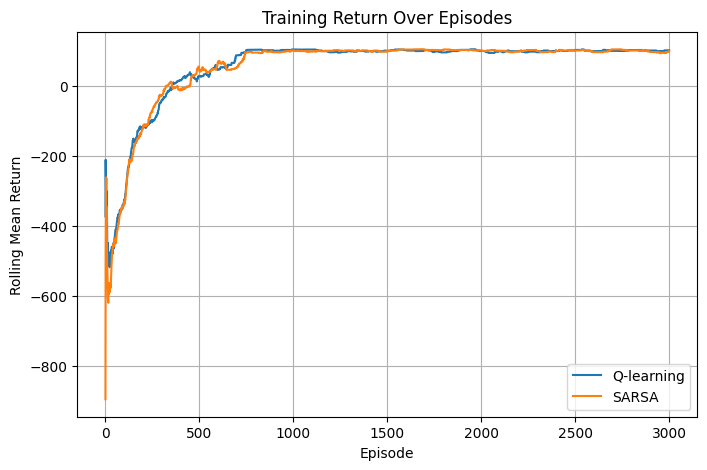

In [72]:
# Plot episode return curves to compare learning speed and stability.
plt.figure(figsize=(8, 5))
plt.plot(q_learning_results["episode"], add_rolling_mean(q_learning_results, "total_reward"), label="Q-learning")
plt.plot(sarsa_results["episode"], add_rolling_mean(sarsa_results, "total_reward"), label="SARSA")
plt.title("Training Return Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Rolling Mean Return")
plt.legend()
plt.grid(True)
plt.show()


The training return curves show that both Q-learning and SARSA improve rapidly during the early episodes and then converge to a stable positive return, indicating that both agents successfully learn effective policies over time.


**Figure 18. Q-learning and SARSA training return over episodes**


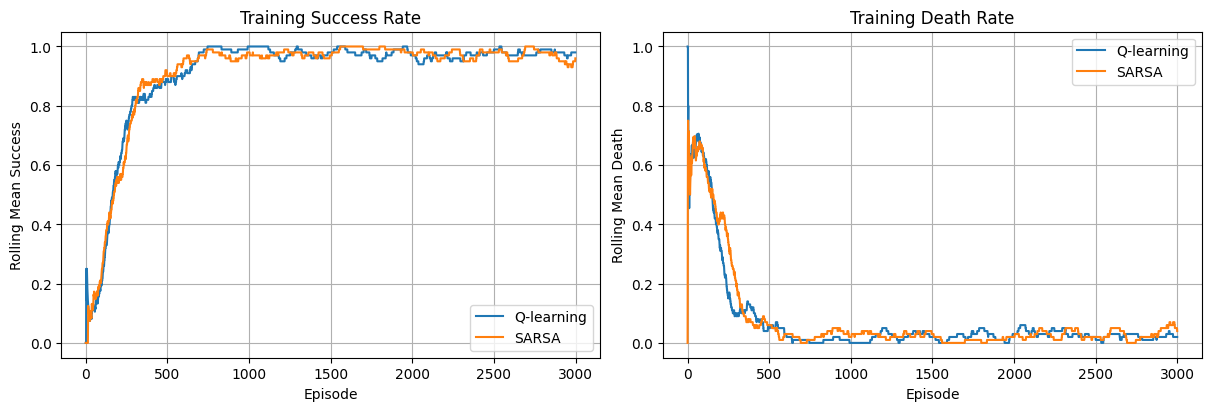

In [73]:
# Plot success and death curves to inspect whether policies become safer over training.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(q_learning_results["episode"], add_rolling_mean(q_learning_results, "success"), label="Q-learning")
axes[0].plot(sarsa_results["episode"], add_rolling_mean(sarsa_results, "success"), label="SARSA")
axes[0].set_title("Training Success Rate")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Rolling Mean Success")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(q_learning_results["episode"], add_rolling_mean(q_learning_results, "death"), label="Q-learning")
axes[1].plot(sarsa_results["episode"], add_rolling_mean(sarsa_results, "death"), label="SARSA")
axes[1].set_title("Training Death Rate")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Rolling Mean Death")
axes[1].legend()
axes[1].grid(True)

plt.show()


The curves show that both Q-learning and SARSA gradually increase their training success rate to nearly 1.0 while reducing the death rate close to 0, indicating that both agents learn safer and more successful behaviours over time.


**Figure 19. Q-learning and SARSA training success and death rates**


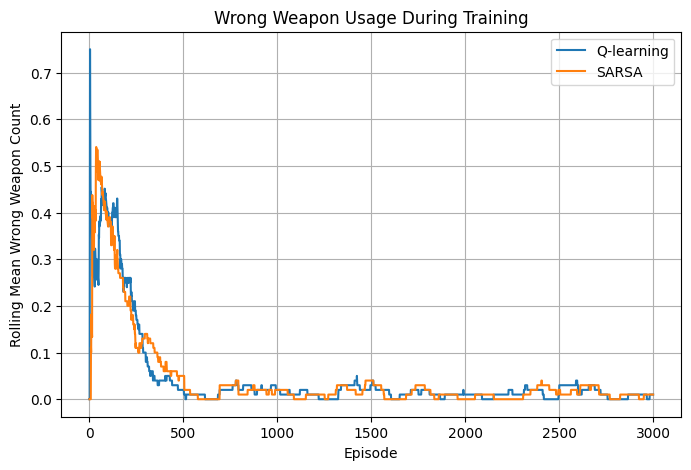

In [74]:
# Plot wrong-weapon usage to check whether the agent learns monster-specific combat decisions.
plt.figure(figsize=(8, 5))
plt.plot(q_learning_results["episode"], add_rolling_mean(q_learning_results, "wrong_weapon_count"), label="Q-learning")
plt.plot(sarsa_results["episode"], add_rolling_mean(sarsa_results, "wrong_weapon_count"), label="SARSA")
plt.title("Wrong Weapon Usage During Training")
plt.xlabel("Episode")
plt.ylabel("Rolling Mean Wrong Weapon Count")
plt.legend()
plt.grid(True)
plt.show()


**Figure 20. Wrong weapon usage during training**

By the end of training, both algorithms show strong training performance and no wrong weapon use in the final logged episodes. This suggests that the local combat rule is learnable from the designed state and reward signals.


### 4.4.9 Validation and Test Evaluation

After training, both learned policies are evaluated greedily, with no epsilon exploration. This is important because evaluation should measure the learned policy itself rather than random exploratory actions.

The selected metrics are mean total reward, mean steps, success rate, death rate, mean correct kills, mean wrong weapon count, and mean wall hits. Mean total reward summarises the reward objective, but it is not sufficient alone. Mean steps measures efficiency. Success and death rates measure task completion and safety. Correct kills and wrong weapon count measure whether the agent learned combat decisions. Wall hits measure navigation quality. Together, these metrics give a more complete view than success rate alone.


In [75]:
# Evaluate a learned Q-table using a greedy policy and record performance metrics
def evaluate_policy(env, Q, maze_seeds, max_steps=500):
    results = []

    # Test the learned policy on each maze seed
    for episode, maze_seed in enumerate(maze_seeds):
        obs, info = env.reset(seed=int(maze_seed))
        state = obs_to_state(obs)

        # Initialise episode-level metrics
        total_reward = 0
        steps = 0
        success = False
        death = False
        correct_kills = 0
        wrong_weapon_count = 0
        hit_wall_count = 0

        # Run the learned policy until termination or the maximum step limit
        for step in range(max_steps):
            # Select the action with the highest Q-value
            action = int(np.argmax(Q[state]))
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = obs_to_state(next_obs)

            # Update reward and behaviour metrics
            total_reward += reward
            steps += 1
            correct_kills += int(info.get("correct_kill", False))
            wrong_weapon_count += int(info.get("wrong_weapon", False))
            hit_wall_count += int(info.get("hit_wall", False))
            success = success or bool(info.get("success", False))
            death = death or bool(info.get("death", False))

            state = next_state
            if terminated or truncated:
                break

        # Store the evaluation result for the current maze
        results.append({
            "episode": episode,
            "maze_seed": int(maze_seed),
            "total_reward": total_reward,
            "steps": steps,
            "success": success,
            "death": death,
            "correct_kills": correct_kills,
            "wrong_weapon_count": wrong_weapon_count,
            "hit_wall_count": hit_wall_count,
        })

    # Return evaluation results as a DataFrame
    return pd.DataFrame(results)


In [76]:
# Evaluate Q-learning and SARSA separately on validation and test seeds.
q_learning_validation_eval = evaluate_policy(env, q_learning_Q, VALIDATION_SEEDS, max_steps=MAX_STEPS)
sarsa_validation_eval = evaluate_policy(env, sarsa_Q, VALIDATION_SEEDS, max_steps=MAX_STEPS)

q_learning_test_eval = evaluate_policy(env, q_learning_Q, TEST_SEEDS, max_steps=MAX_STEPS)
sarsa_test_eval = evaluate_policy(env, sarsa_Q, TEST_SEEDS, max_steps=MAX_STEPS)

q_learning_validation_eval.head()


,episode,maze_seed,total_reward,steps,success,death,correct_kills,wrong_weapon_count,hit_wall_count
0,0,100,98,14,True,False,1,0,0
1,1,101,-489,500,False,False,1,0,0
2,2,102,102,21,True,False,2,0,0
3,3,103,108,15,True,False,2,0,0
4,4,104,102,21,True,False,2,0,0


### 4.4.10 Learned Path Visualisation

A learned path is visualised on a test seed to provide qualitative evidence of what the policy actually does in the maze. This is useful because summary metrics can hide path loops, detours, or risky movements.


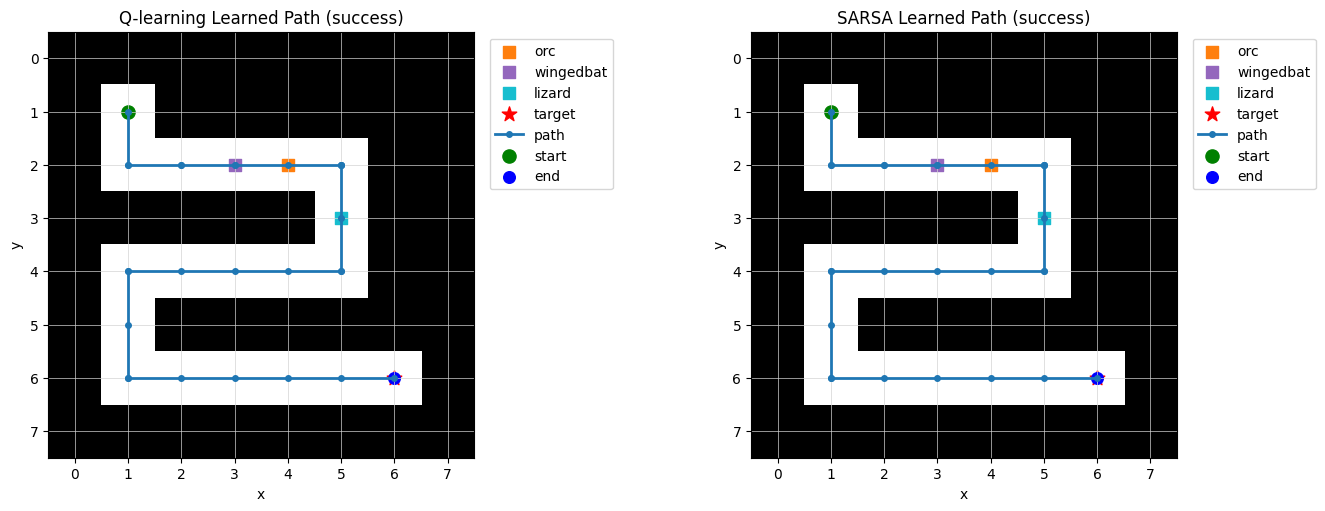

Q-learning path length: 26 Success: True Death: False
SARSA path length: 26 Success: True Death: False


In [77]:
# Roll out one learned policy and record its path, actions, events, and final outcome
def rollout_learned_path(env, Q, max_steps=500, maze_seed=None):
    if maze_seed is None:
        maze_seed = TEST_SEEDS[0]

    # Reset the environment and save the maze layout
    obs, info = env.reset(seed=int(maze_seed))
    maze_array = env.maze.encode_maze_to_array().copy()

    # Initialise path and event records
    path = [tuple(np.array(obs["robot_position"]).astype(int))]
    actions_taken = []
    events = []
    success = False
    death = False

    # Follow the greedy policy until termination or the step limit
    for step in range(max_steps):
        state = obs_to_state(obs)
        action = int(np.argmax(Q[state]))
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Store action, event, and robot position
        actions_taken.append(ACTION_NAMES[action])
        events.append(info.get("event", "step"))
        path.append(tuple(np.array(next_obs["robot_position"]).astype(int)))

        success = success or bool(info.get("success", False))
        death = death or bool(info.get("death", False))
        obs = next_obs

        if terminated or truncated:
            break

    # Convert the path into a DataFrame for plotting
    path_df = pd.DataFrame(path, columns=["x", "y"])
    return path_df, actions_taken, events, maze_array, success, death


# Plot the learned path on top of the maze, including walls, monsters, target, start, and end
def plot_learned_path(ax, path_df, maze_array, title, success, death):
    # Draw wall cells as the maze background
    wall_mask = maze_array.T == 1
    ax.imshow(wall_mask, cmap="Greys", origin="upper")

    # Define colours and markers for different monster types
    monster_styles = {
        3: ("orc", "tab:orange", "s"),
        4: ("wingedbat", "tab:purple", "s"),
        5: ("lizard", "tab:cyan", "s"),
    }

    # Plot monster positions
    for value, (label, color, marker) in monster_styles.items():
        cells = np.argwhere(maze_array.T == value)
        if len(cells) > 0:
            ax.scatter(cells[:, 1], cells[:, 0], c=color, marker=marker, s=80, label=label)

    # Plot the target position
    target_cells = np.argwhere(maze_array.T == 2)
    if len(target_cells) > 0:
        ax.scatter(target_cells[:, 1], target_cells[:, 0], c="red", s=120, marker="*", label="target")

    # Plot the learned path, start position, and end position
    ax.plot(path_df["x"], path_df["y"], marker="o", linewidth=2, markersize=4, label="path")
    ax.scatter(path_df.iloc[0]["x"], path_df.iloc[0]["y"], c="green", s=90, label="start")
    ax.scatter(path_df.iloc[-1]["x"], path_df.iloc[-1]["y"], c="blue", s=70, label="end")

    # Add plot title, grid, labels, and legend
    outcome = "success" if success else "death" if death else "not reached"
    ax.set_title(f"{title} Learned Path ({outcome})")
    ax.set_xticks(range(maze_array.shape[0]))
    ax.set_yticks(range(maze_array.shape[1]))
    ax.grid(color="lightgray", linewidth=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))


# Roll out Q-learning and SARSA on the same test maze seed
q_path_df, q_actions, q_events, q_maze_array, q_path_success, q_path_death = rollout_learned_path(
    env, q_learning_Q, max_steps=MAX_STEPS, maze_seed=TEST_SEEDS[0]
)

sarsa_path_df, sarsa_actions, sarsa_events, sarsa_maze_array, sarsa_path_success, sarsa_path_death = rollout_learned_path(
    env, sarsa_Q, max_steps=MAX_STEPS, maze_seed=TEST_SEEDS[0]
)

# Plot the learned paths of both agents side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plot_learned_path(axes[0], q_path_df, q_maze_array, "Q-learning", q_path_success, q_path_death)
plot_learned_path(axes[1], sarsa_path_df, sarsa_maze_array, "SARSA", sarsa_path_success, sarsa_path_death)
plt.show()

# Print path length and outcome for both agents
print("Q-learning path length:", len(q_path_df) - 1, "Success:", q_path_success, "Death:", q_path_death)
print("SARSA path length:", len(sarsa_path_df) - 1, "Success:", sarsa_path_success, "Death:", sarsa_path_death)


**Figure 21. Learned paths for Q-learning and SARSA on a test maze**


### 4.4.11 Final Quantitative Comparison


In [78]:
# Summarise validation and test metrics for the baselines, Q-learning, and SARSA.
def summarise_results(split_name, method_name, results_df):
    return {
        "Split": split_name,
        "Method": method_name,
        "Mean total reward": results_df["total_reward"].mean(),
        "Mean steps": results_df["steps"].mean(),
        "Success rate": results_df["success"].mean(),
        "Death rate": results_df["death"].mean(),
        "Mean correct kills": results_df["correct_kills"].mean(),
        "Mean wrong weapon count": results_df["wrong_weapon_count"].mean(),
        "Mean wall hits": results_df["hit_wall_count"].mean(),
    }


summary_df = pd.DataFrame([
    summarise_results("Validation", "Random policy", random_validation_results),
    summarise_results("Validation", "Heuristic policy", heuristic_validation_results),
    summarise_results("Validation", "Q-learning", q_learning_validation_eval),
    summarise_results("Validation", "SARSA", sarsa_validation_eval),
    summarise_results("Test", "Random policy", random_test_results),
    summarise_results("Test", "Heuristic policy", heuristic_test_results),
    summarise_results("Test", "Q-learning", q_learning_test_eval),
    summarise_results("Test", "SARSA", sarsa_test_eval),
])

summary_df


,Split,Method,Mean total reward,Mean steps,Success rate,Death rate,Mean correct kills,Mean wrong weapon count,Mean wall hits
0,Validation,Random policy,-580.04,295.80,0.00,0.56,0.80,0.44,37.44
1,Validation,Heuristic policy,74.32,52.20,1.00,0.00,2.32,0.00,0.00
2,Validation,Q-learning,-35.08,113.88,0.80,0.00,1.60,0.00,0.00
3,Validation,SARSA,9.08,94.68,0.84,0.00,1.72,0.00,0.00
4,Test,Random policy,-515.16,264.12,0.12,0.60,0.56,0.48,33.96
5,Test,Heuristic policy,80.80,47.48,1.00,0.00,2.48,0.00,0.00
6,Test,Q-learning,-156.88,230.16,0.56,0.00,1.52,0.00,0.00
7,Test,SARSA,-156.88,230.16,0.56,0.00,1.52,0.00,0.00


**Table 9. Validation and test comparison of baselines, Q-learning, and SARSA**

On validation seeds, Q-learning reaches a success rate of `0.80` with mean reward `-35.08`, while SARSA reaches a slightly higher success rate of `0.84` with mean reward `9.08`. Both learned methods avoid death and wrong weapon use during validation. On test seeds, Q-learning and SARSA both achieve success rate `0.56`, death rate `0.00`, and mean reward `-156.88`. This indicates that both agents learned safe combat behaviour but did not generalise perfectly to all unseen maze layouts.


In [79]:
# Save the RL summary, training logs, and validation/test evaluation logs.
Path("../report").mkdir(exist_ok=True)

summary_df.to_csv("../report/task3_rl_summary.csv", index=False)
q_learning_results.to_csv("../report/task3_q_learning_training.csv", index=False)
sarsa_results.to_csv("../report/task3_sarsa_training.csv", index=False)

random_validation_results.to_csv("../report/task3_random_validation_eval.csv", index=False)
heuristic_validation_results.to_csv("../report/task3_heuristic_validation_eval.csv", index=False)
q_learning_validation_eval.to_csv("../report/task3_q_learning_validation_eval.csv", index=False)
sarsa_validation_eval.to_csv("../report/task3_sarsa_validation_eval.csv", index=False)

random_test_results.to_csv("../report/task3_random_test_eval.csv", index=False)
heuristic_test_results.to_csv("../report/task3_heuristic_test_eval.csv", index=False)
q_learning_test_eval.to_csv("../report/task3_q_learning_test_eval.csv", index=False)
sarsa_test_eval.to_csv("../report/task3_sarsa_test_eval.csv", index=False)


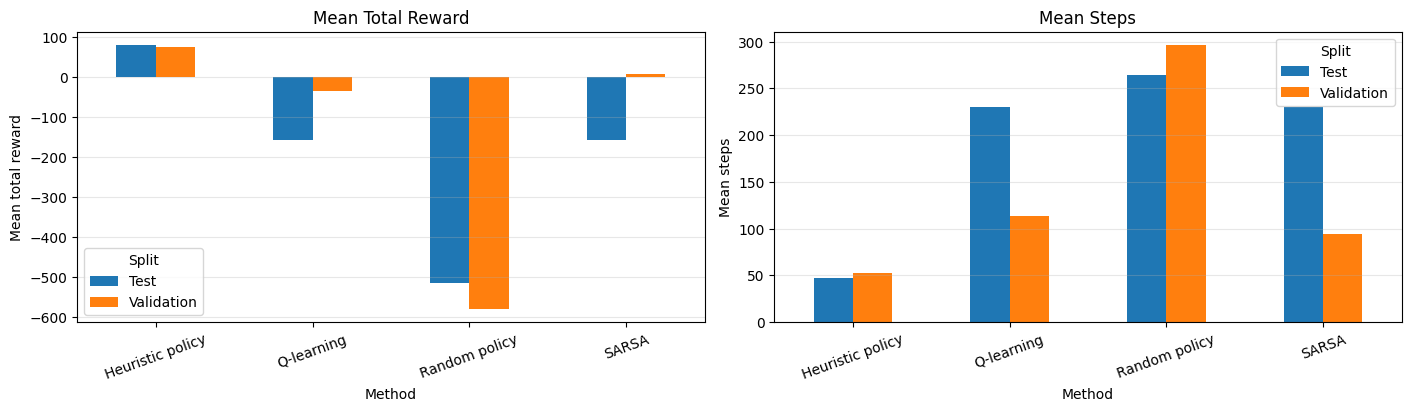

In [80]:
# Compare mean reward and mean steps across methods on validation and test splits.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

for ax, metric, title in [
    (axes[0], "Mean total reward", "Mean Total Reward"),
    (axes[1], "Mean steps", "Mean Steps"),
]:
    pivot_df = summary_df.pivot(index="Method", columns="Split", values=metric)
    pivot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.show()


**Figure 22. Mean reward and mean steps across validation and test splits**


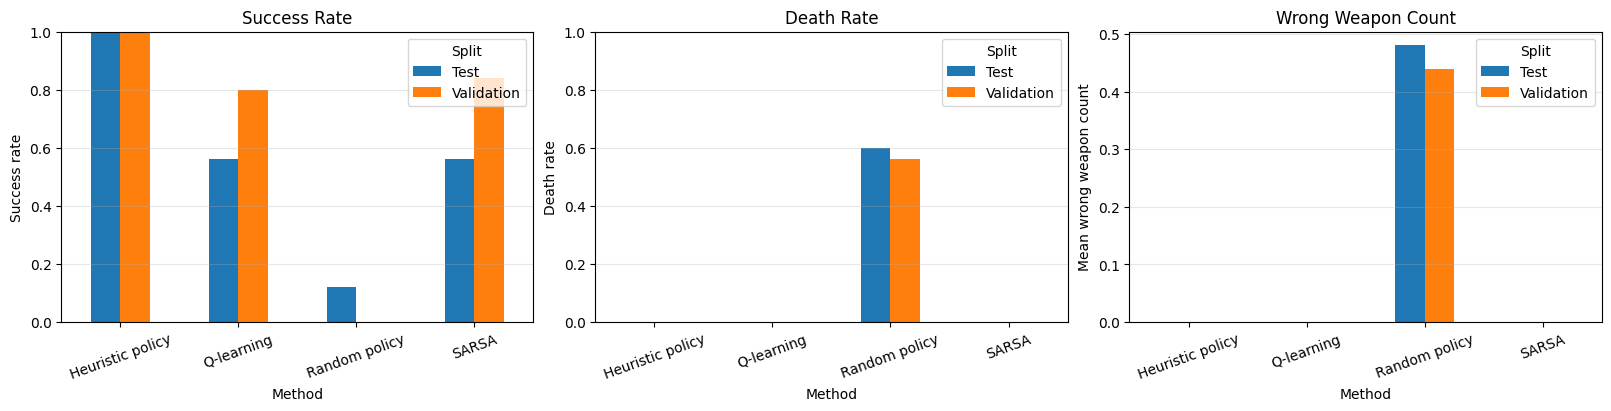

In [81]:
# Compare success rate, death rate, and wrong-weapon count across methods on both splits.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, metric, title in [
    (axes[0], "Success rate", "Success Rate"),
    (axes[1], "Death rate", "Death Rate"),
    (axes[2], "Mean wrong weapon count", "Wrong Weapon Count"),
]:
    pivot_df = summary_df.pivot(index="Method", columns="Split", values=metric)
    pivot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    if metric in {"Success rate", "Death rate"}:
        ax.set_ylim(0, 1)

plt.show()


**Figure 23. Success rate, death rate, and wrong weapon count across validation and test splits**


## 4.5 Algorithm-Specific Evaluation

The random baseline confirms the difficulty of the task. On the test split it obtains mean reward `-515.16`, success rate `0.12`, death rate `0.60`, and an average of `33.96` wall hits. This shows that the environment strongly penalises blind action and that navigation plus combat cannot be solved by chance.

The heuristic baseline is very strong in the current environment. It reaches success rate `1.00` on both validation and test, with no deaths, no wrong weapon use, and no wall hits. Its mean test reward is `80.80` with mean `47.48` steps. This indicates that the fixed start, fixed target, and local monster rules make a simple reactive strategy highly effective.

Q-learning learns safe combat and avoids deaths and wrong weapon use in both validation and test evaluation. However, its test success rate falls to `0.56`, and its mean steps rise to `230.16`, meaning that the learned greedy policy often fails to finish within the step limit on unseen mazes. This suggests incomplete generalisation rather than unsafe behaviour.

SARSA performs slightly better than Q-learning on validation, with success rate `0.84` and mean reward `9.08`, but it has the same test performance as Q-learning in the recorded results. The expected safety advantage of SARSA is not very visible here because both algorithms already avoid deaths and wrong weapon errors. The main remaining weakness for both is robust path planning on unseen mazes.


## 4.6 Comparison Between Q-Learning, SARSA, and Baselines

Compared with the random baseline, both Q-learning and SARSA clearly improve safety and combat decisions. They reduce death rate from `0.60` on the random test baseline to `0.00`, and reduce wrong weapon use from `0.48` to `0.00`. This is strong evidence that the reward design and perception features teach the agents the key safety and weapon-selection rules.

However, compared with the heuristic baseline, the learned agents are weaker in final task completion. The heuristic policy reaches all validation and test targets, while Q-learning and SARSA reach only `56%` of test mazes. This does not mean reinforcement learning failed completely; rather, it shows that the current state representation and tabular method are enough for local combat but not always enough for general navigation.

Q-learning and SARSA are very similar in the final test results. SARSA has a small validation advantage, which is consistent with the idea that on-policy learning can be more cautious, but the test split does not show a meaningful difference. The more important finding is that both methods generalise imperfectly from train seeds `0-99` to test seeds `125-149`.


## 4.7 Critical Analysis, Limitations, and Future Work

The completed work successfully extends the maze environment with combat interactions, defines a compact state representation, implements two baselines, trains two tabular RL algorithms, and evaluates them on separated train, validation, and test seeds. The evaluation also looks beyond total reward by measuring success, death, combat correctness, wall hits, and path efficiency.

The main limitation is generalisation. The state includes only local perception and no memory of visited cells or full maze structure. This helps keep the Q-table manageable, but it limits long-term planning. If perception is too small, the agent may not know whether a turn leads to progress or a loop. The fixed start and target also make the task easier than a fully general navigation problem, and the strong heuristic baseline shows that the current environment can often be solved with simple local rules.

Future work could randomise the start and target positions to test stronger generalisation. The environment could also add friendly entities such as `human` or `halfling`, requiring the robot to distinguish friend from foe and choose different interactions rather than attacking every visible character. More entity types, larger mazes, partial observability, and dynamic monsters would increase task difficulty. Methodologically, future work could use a larger local observation window, add visit memory, or replace the tabular Q-table with function approximation or deep reinforcement learning so that policies can generalise better across unseen maze layouts.


# References

Cheng, C.-A., Kolobov, A. and Swaminathan, A. (2021) ‘Heuristic-guided reinforcement learning’, Advances in Neural Information Processing Systems, 34, pp. 13550–13563.

Rubiños, M., Díaz-Longueira, A., Timiraos, M., Michelena, Á., García-Ordás, M.T. and Alaiz-Moretón, H. (2024) A comparative analysis of algorithms and metrics to perform clustering. In: Lecture notes in networks and systems [online]. pp. 63–72.